# ONLY Fourier Path 22 - Image High-Pass + Feature Fourier Hybrid Sweep, No Augmentation

This notebook tries to beat the current Fourier-only raw mAP50 leader:

- fixed image Fourier high-pass `sigma=50`, `alpha=0.10`
- prior labeled test mask mAP50: `0.345105`

Strict contract:

- Kaggle-ready Roboflow download
- stratified grouped-specimen split, seed 42
- `yolo11n-seg.pt` family
- no explicit YOLO augmentation
- hidden/default Ultralytics Albumentations hook disabled for every row
- Fourier-only deterministic preprocessing and/or Fourier feature modules
- no random train-copy augmentation

The key hypothesis is that the best raw-mAP image-space Fourier signal can be stacked with feature-domain Fourier refinement while still remaining a Fourier-only experiment.


## Outputs To Download

After the run, download or preserve:

- `only_fourier_hybrid_sweep_no_aug_hook_off_seed42_summary.csv`
- `only_fourier_hybrid_sweep_no_aug_hook_off_seed42_paper_row.csv`
- `only_fourier_hybrid_sweep_no_aug_hook_off_seed42_partial.csv` if interrupted
- `train_args_only_fourier_hybrid_sweep_no_aug_hook_off_seed42.json`
- `split_manifests/`
- generated Fourier hybrid model YAMLs under `model_yamls/`
- selected `weights/best.pt`
- selected run `results.csv`
- `only_fourier_hybrid_sweep_no_aug_hook_off_seed42_outputs.zip`

Primary target: beat labeled-only test mask mAP50 `0.345105` from fixed image high-pass `sigma=50 alpha=0.10`.


## Run Controls

In [1]:
# Run controls for ONLY_fourier path 22.
from pathlib import Path

EXECUTION_PLAN = 'only_fourier_22_hybrid_sweep_no_aug_hook_off_seed42'
SMOKE_RUN = False
SEEDS = [42]
DISABLE_ULTRALYTICS_ALBUMENTATIONS = True
PINNED_ULTRALYTICS_VERSION = '8.4.62'

YOLO_MODELS = [
    'yolo11n-seg.pt',
]

SPLIT_POLICIES = [
    {
        'key': 'stratified_grouped_specimen',
        'name': 'Stratified grouped-specimen split',
        'description': 'Disease-stratified split where all images from one shrimp stay together.',
    },
]

if Path('/kaggle/working').exists():
    WORK_DIR = Path('/kaggle/working')
elif Path('/content').exists():
    WORK_DIR = Path('/content')
else:
    WORK_DIR = Path.cwd()

DATASET_DIR = WORK_DIR / 'shrimpDisHandSegV2-1'
EXPERIMENT_ROOT = WORK_DIR / 'shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42'
RUNS_DIR = WORK_DIR / 'runs' / 'segment'
REPORT_DIR = EXPERIMENT_ROOT / 'reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print('EXECUTION_PLAN:', EXECUTION_PLAN)
print('WORK_DIR:', WORK_DIR)
print('DATASET_DIR:', DATASET_DIR)
print('SMOKE_RUN:', SMOKE_RUN)
print('SEEDS:', SEEDS)
print('DISABLE_ULTRALYTICS_ALBUMENTATIONS:', DISABLE_ULTRALYTICS_ALBUMENTATIONS)
print('PINNED_ULTRALYTICS_VERSION:', PINNED_ULTRALYTICS_VERSION)
print('YOLO_MODELS:', YOLO_MODELS)
print('SPLIT_POLICIES:', [p['key'] for p in SPLIT_POLICIES])


EXECUTION_PLAN: only_fourier_22_hybrid_sweep_no_aug_hook_off_seed42
WORK_DIR: /kaggle/working
DATASET_DIR: /kaggle/working/shrimpDisHandSegV2-1
SMOKE_RUN: False
SEEDS: [42]
DISABLE_ULTRALYTICS_ALBUMENTATIONS: True
PINNED_ULTRALYTICS_VERSION: 8.4.62
YOLO_MODELS: ['yolo11n-seg.pt']
SPLIT_POLICIES: ['stratified_grouped_specimen']


## Install Dependencies

In [2]:
import importlib.metadata
import subprocess
import sys


def installed_version(package_name):
    try:
        return importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        return None


if installed_version('ultralytics') != PINNED_ULTRALYTICS_VERSION:
    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        f'ultralytics=={PINNED_ULTRALYTICS_VERSION}',
    ])

for package_name in ['roboflow', 'pandas', 'pyyaml', 'seaborn']:
    if installed_version(package_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])

print('Ultralytics installed version:', installed_version('ultralytics'))
print('Expected version:', PINNED_ULTRALYTICS_VERSION)
assert installed_version('ultralytics') == PINNED_ULTRALYTICS_VERSION, 'Ultralytics version mismatch.'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 514.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 69.1 MB/s eta 0:00:00
Ultralytics installed version: 8.4.62
Expected version: 8.4.62


In [3]:
# Patch Ultralytics with feature-Fourier modules for image+feature hybrid rows.
import ast
import importlib.util
import py_compile
import re
import shutil
from pathlib import Path

spec = importlib.util.find_spec('ultralytics')
if spec is None or spec.origin is None:
    raise RuntimeError('Cannot locate installed ultralytics package for Fourier hybrid patching.')

ULTRA_PKG_DIR = Path(spec.origin).parent
CONV_PY = ULTRA_PKG_DIR / 'nn' / 'modules' / 'conv.py'
MODULES_INIT_PY = ULTRA_PKG_DIR / 'nn' / 'modules' / '__init__.py'
TASKS_PY = ULTRA_PKG_DIR / 'nn' / 'tasks.py'
MODEL_YAML_DIR = EXPERIMENT_ROOT / 'model_yamls'
MODEL_YAML_DIR.mkdir(parents=True, exist_ok=True)

print('Ultralytics package dir:', ULTRA_PKG_DIR)


def backup_once(path):
    backup = path.with_suffix(path.suffix + '.bak_fourier_hybrid_no_aug')
    if not backup.exists():
        shutil.copy2(path, backup)
        print('Backup created:', backup)


for patch_path in [CONV_PY, MODULES_INIT_PY, TASKS_PY]:
    if not patch_path.exists():
        raise FileNotFoundError(patch_path)
    backup_once(patch_path)


HYBRID_MODULE_CODE = '''

# FDDEM_HYBRID_MODULES_V1
class FDDEM(nn.Module):
    def __init__(self, c1, c2=None, num_bands=2, init_gamma=0.0):
        super().__init__()
        c2 = c1 if c2 is None else c2
        self.num_bands = int(num_bands)
        self.proj = nn.Identity() if c1 == c2 else nn.Conv2d(c1, c2, kernel_size=1, stride=1, padding=0)
        self.spatial = nn.Sequential(
            nn.Conv2d(c2, c2, kernel_size=3, stride=1, padding=1, groups=1, bias=False),
            nn.BatchNorm2d(c2),
            nn.SiLU(),
        )
        self.complex_weight = nn.Parameter(torch.zeros(self.num_bands, c2, 1, 1, 2))
        with torch.no_grad():
            self.complex_weight[..., 0].fill_(1.0)
        self.mix = nn.Sequential(
            nn.Conv2d(c2 * (self.num_bands + 1), c2, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(c2),
            nn.SiLU(),
        )
        self.gamma = nn.Parameter(torch.tensor(float(init_gamma)))

    def _radial_masks(self, height, width, device, dtype):
        fy = torch.fft.fftfreq(height, device=device, dtype=torch.float32).abs().view(height, 1)
        fx = torch.fft.rfftfreq(width, device=device, dtype=torch.float32).abs().view(1, width // 2 + 1)
        radius = torch.sqrt(fy * fy + fx * fx)
        masks = []
        if self.num_bands >= 1:
            masks.append(torch.sigmoid((radius - 0.12) * 40.0))
        if self.num_bands >= 2:
            masks.append(torch.exp(-((radius - 0.22) ** 2) / (2.0 * 0.08 ** 2)))
        while len(masks) < self.num_bands:
            center = 0.08 + 0.08 * len(masks)
            masks.append(torch.exp(-((radius - center) ** 2) / (2.0 * 0.05 ** 2)))
        return torch.stack(masks, dim=0).to(dtype=dtype).view(self.num_bands, 1, height, width // 2 + 1)

    def forward(self, x):
        x = self.proj(x)
        height, width = x.shape[-2:]
        dtype = x.dtype
        freq = torch.fft.rfft2(x.float(), norm='ortho')
        masks = self._radial_masks(height, width, x.device, freq.real.dtype)
        gains = torch.view_as_complex(self.complex_weight.float())
        branches = []
        for band_idx in range(self.num_bands):
            filtered = freq * masks[band_idx] * gains[band_idx]
            branch = torch.fft.irfft2(filtered, s=(height, width), norm='ortho').to(dtype=dtype)
            branches.append(branch)
        detail = self.mix(torch.cat([self.spatial(x), *branches], dim=1))
        return x + self.gamma.to(dtype=dtype) * detail


class FDDEMCutoff(nn.Module):
    def __init__(self, c1, c2=None, cutoff=0.14, init_gamma=0.01):
        super().__init__()
        c2 = c1 if c2 is None else c2
        self.cutoff = float(cutoff)
        self.proj = nn.Identity() if c1 == c2 else nn.Conv2d(c1, c2, kernel_size=1, stride=1, padding=0)
        self.spatial = nn.Sequential(
            nn.Conv2d(c2, c2, kernel_size=3, stride=1, padding=1, groups=1, bias=False),
            nn.BatchNorm2d(c2),
            nn.SiLU(),
        )
        self.complex_weight = nn.Parameter(torch.zeros(1, c2, 1, 1, 2))
        with torch.no_grad():
            self.complex_weight[..., 0].fill_(1.0)
        self.mix = nn.Sequential(
            nn.Conv2d(c2 * 2, c2, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(c2),
            nn.SiLU(),
        )
        self.gamma = nn.Parameter(torch.tensor(float(init_gamma)))

    def _highpass_mask(self, height, width, device, dtype):
        fy = torch.fft.fftfreq(height, device=device, dtype=torch.float32).abs().view(height, 1)
        fx = torch.fft.rfftfreq(width, device=device, dtype=torch.float32).abs().view(1, width // 2 + 1)
        radius = torch.sqrt(fy * fy + fx * fx)
        mask = torch.sigmoid((radius - self.cutoff) * 40.0)
        return mask.to(dtype=dtype).view(1, 1, height, width // 2 + 1)

    def forward(self, x):
        x = self.proj(x)
        height, width = x.shape[-2:]
        dtype = x.dtype
        freq = torch.fft.rfft2(x.float(), norm='ortho')
        mask = self._highpass_mask(height, width, x.device, freq.real.dtype)
        gain = torch.view_as_complex(self.complex_weight.float())[0]
        filtered = freq * mask * gain
        branch = torch.fft.irfft2(filtered, s=(height, width), norm='ortho').to(dtype=dtype)
        detail = self.mix(torch.cat([self.spatial(x), branch], dim=1))
        return x + self.gamma.to(dtype=dtype) * detail
'''

conv_text = CONV_PY.read_text(encoding='utf-8')
if 'FDDEM_HYBRID_MODULES_V1' not in conv_text:
    CONV_PY.write_text(conv_text.rstrip() + HYBRID_MODULE_CODE + '\n', encoding='utf-8')
    py_compile.compile(str(CONV_PY), doraise=True)
    print('Patched conv.py with Fourier hybrid modules.')
else:
    print('conv.py already contains Fourier hybrid modules; leaving existing patch in place.')


def add_names_to_parenthesized_import(text, anchor, names):
    start = text.find(anchor)
    if start == -1:
        return text, False
    close = text.find(')', start)
    if close == -1:
        return text, False
    block = text[start:close]
    missing = [name for name in names if name not in block]
    if not missing:
        return text, True
    insert = ''.join(f'    {name},\n' for name in missing)
    return text[:close] + insert + text[close:], True


def add_names_to_base_modules(text, names):
    pattern = r'(base_modules\s*=\s*frozenset\(\s*\{)(.*?)(\}\s*\))'
    match = re.search(pattern, text, flags=re.DOTALL)
    if not match:
        raise RuntimeError('Could not locate base_modules frozenset in tasks.py')
    body = match.group(2)
    missing = [name for name in names if name not in body]
    if not missing:
        return text
    body = body.rstrip() + ''.join(f'\n                {name},' for name in missing) + '\n            '
    return text[:match.start(2)] + body + text[match.end(2):]


CUSTOM_MODULES = ['FDDEM', 'FDDEMCutoff']

init_text = MODULES_INIT_PY.read_text(encoding='utf-8')
init_text, ok = add_names_to_parenthesized_import(init_text, 'from .conv import (', CUSTOM_MODULES)
if not ok:
    for name in CUSTOM_MODULES:
        line = f'from .conv import {name}\n'
        if line.strip() not in init_text:
            init_text += '\n' + line
if '__all__' in init_text:
    idx = init_text.find('__all__ = (')
    if idx != -1:
        close = init_text.find(')', idx)
        block = init_text[idx:close]
        insert = ''.join(f'    "{name}",\n' for name in CUSTOM_MODULES if f'"{name}"' not in block and f"'{name}'" not in block)
        init_text = init_text[:close] + insert + init_text[close:]
MODULES_INIT_PY.write_text(init_text, encoding='utf-8')
print('Patched modules __init__.py for Fourier hybrid exports.')

tasks_text = TASKS_PY.read_text(encoding='utf-8')
tasks_text, ok = add_names_to_parenthesized_import(tasks_text, 'from ultralytics.nn.modules import (', CUSTOM_MODULES)
if not ok:
    raise RuntimeError('Could not locate ultralytics.nn.modules import block in tasks.py')
tasks_text = add_names_to_base_modules(tasks_text, CUSTOM_MODULES)
TASKS_PY.write_text(tasks_text, encoding='utf-8')
ast.parse(TASKS_PY.read_text(encoding='utf-8'))
print('Patched tasks.py for Fourier hybrid YAML parsing.')

BASE_YAML_TEMPLATE = '''nc: 2
scales:
  n: [0.50, 0.25, 1024]
  s: [0.50, 0.50, 1024]
  m: [0.50, 1.00, 512]
  l: [1.00, 1.00, 512]
  x: [1.00, 1.50, 512]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 2, C3k2, [256, False, 0.25]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 2, C3k2, [512, False, 0.25]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 2, C3k2, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 2, C3k2, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]
  - [-1, 2, C2PSA, [1024]]

head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 2, C3k2, [256, False]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 13], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 10], 1, Concat, [1]]
  - [-1, 2, C3k2, [1024, True]]
{hybrid_layers}
'''

HYBRID_YAMLS = {
    'w6_img_hp50a010_fddemcutoff_c014_g001': '''  # Image high-pass plus FDDEMCutoff cutoff 0.14, gamma 0.01.
  - [16, 1, FDDEMCutoff, [256, 0.14, 0.01]]
  - [19, 1, FDDEMCutoff, [512, 0.14, 0.01]]
  - [22, 1, FDDEMCutoff, [1024, 0.14, 0.01]]
  - [[23, 24, 25], 1, Segment, [nc, 32, 256]]''',
    'w7_img_hp50a010_fddem_twoband_identity': '''  # Image high-pass plus 017 F3 FDDEM two-band identity-gated reference.
  - [16, 1, FDDEM, [256, 2, 0.00]]
  - [19, 1, FDDEM, [512, 2, 0.00]]
  - [22, 1, FDDEM, [1024, 2, 0.00]]
  - [[23, 24, 25], 1, Segment, [nc, 32, 256]]''',
}

HYBRID_YAML_PATHS = {}
for key, layers in HYBRID_YAMLS.items():
    yaml_path = MODEL_YAML_DIR / f'yolo11n-seg-{key}.yaml'
    yaml_path.write_text(BASE_YAML_TEMPLATE.format(hybrid_layers=layers), encoding='utf-8')
    HYBRID_YAML_PATHS[key] = yaml_path
    print('Created Fourier hybrid model YAML:', key, yaml_path)

import ultralytics
from ultralytics import YOLO

print('Ultralytics version:', ultralytics.__version__)
print('Expected version:', PINNED_ULTRALYTICS_VERSION)
assert ultralytics.__version__ == PINNED_ULTRALYTICS_VERSION, 'Ultralytics version mismatch.'

for yaml_key, yaml_path in HYBRID_YAML_PATHS.items():
    _smoke_model = YOLO(str(yaml_path))
    print('Fourier hybrid YAML smoke build OK:', yaml_key, yaml_path.name)
    del _smoke_model


Ultralytics package dir: /usr/local/lib/python3.12/dist-packages/ultralytics
Backup created: /usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/conv.py.bak_fourier_hybrid_no_aug
Backup created: /usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/__init__.py.bak_fourier_hybrid_no_aug
Backup created: /usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py.bak_fourier_hybrid_no_aug
Patched conv.py with Fourier hybrid modules.
Patched modules __init__.py for Fourier hybrid exports.
Patched tasks.py for Fourier hybrid YAML parsing.
Created Fourier hybrid model YAML: w6_img_hp50a010_fddemcutoff_c014_g001 /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/model_yamls/yolo11n-seg-w6_img_hp50a010_fddemcutoff_c014_g001.yaml
Created Fourier hybrid model YAML: w7_img_hp50a010_fddem_twoband_identity /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/model_yamls/yolo11n-seg-w7_img_hp50a010_fddem_twoband_identity.yaml
Creating n

## Dataset Download

In [4]:
import os
from roboflow import Roboflow

ROBOFLOW_API_KEY_DIRECT = 'KOEk0qLzBFDc7zfyxtgs'
ROBOFLOW_WORKSPACE = 'lets-try-this'
ROBOFLOW_PROJECT = 'shrimpdishandsegv2'
ROBOFLOW_VERSION = 1
ROBOFLOW_FORMAT = 'yolo26'


def get_roboflow_api_key():
    if ROBOFLOW_API_KEY_DIRECT.strip():
        return ROBOFLOW_API_KEY_DIRECT.strip()
    try:
        from kaggle_secrets import UserSecretsClient
        key = UserSecretsClient().get_secret('ROBOFLOW_API_KEY')
        if key:
            return key
    except Exception:
        pass
    try:
        from google.colab import userdata
        key = userdata.get('ROBOFLOW_API_KEY')
        if key:
            return key
    except Exception:
        pass
    return os.environ.get('ROBOFLOW_API_KEY', '').strip()


api_key = get_roboflow_api_key()
if not api_key:
    raise RuntimeError(
        'Missing Roboflow API key. Add a Kaggle or Colab Secret named ROBOFLOW_API_KEY, '
        'set the ROBOFLOW_API_KEY environment variable, or temporarily fill ROBOFLOW_API_KEY_DIRECT.'
    )

rf = Roboflow(api_key=api_key)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
version = project.version(ROBOFLOW_VERSION)
dataset = version.download(ROBOFLOW_FORMAT, location=str(DATASET_DIR))

base_path = str(DATASET_DIR)
data_yaml_path = str(DATASET_DIR / 'data.yaml')
print('Dataset path:', base_path)
print('data.yaml:', data_yaml_path)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /kaggle/working/shrimpDisHandSegV2-1 in yolo26:: 100%|██████████| 2301/2301 [00:00<00:00, 3382.53it/s]


Dataset path: /kaggle/working/shrimpDisHandSegV2-1
data.yaml: /kaggle/working/shrimpDisHandSegV2-1/data.yaml


## Leakage-Safe Split Helpers

In [5]:
import os
import random
import re
import shutil
from collections import defaultdict, Counter
from pathlib import Path

SEED = 42
random.seed(SEED)

base_path = str(DATASET_DIR)
train_path = os.path.join(base_path, 'train')
IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

# Prevent leakage from multiple photos of the same shrimp.
# Expected original filename: <diseasename>-<shrimpid>-img-<imgnum>.jpg
# Roboflow may export names like <diseasename>-<shrimpid>-img-<imgnum>_jpg.rf.<hash>.jpg.
# Example disease names: Healthy, BG, WSSV_BG, WSSV.
GROUP_SPLIT_BY_SHRIMP = True
GROUP_STRATIFY_BY_DISEASE = True
REBUILD_SPLIT_FROM_ALL_SPLITS = True
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10

SHRIMP_NAME_PATTERN = re.compile(
    r'^(?P<disease>Healthy|BG|WSSV_BG|WSSV)-(?P<shrimp_id>.+)-img-(?P<img_num>\d+)$',
    re.IGNORECASE,
)


def normalize_roboflow_stem(stem):
    """Recover the original filename stem from Roboflow-exported names."""
    stem = re.sub(r'_(jpg|jpeg|png|bmp|webp)\.rf\.[0-9a-f]+$', '', stem, flags=re.IGNORECASE)
    stem = re.sub(r'\.rf\.[0-9a-f]+$', '', stem, flags=re.IGNORECASE)
    return stem


for split in ['train', 'valid', 'test']:
    for sub in ['images', 'labels']:
        os.makedirs(os.path.join(base_path, split, sub), exist_ok=True)


def parse_shrimp_group_key(image_name):
    """Return a stable group key so all images from one shrimp stay in one split."""
    stem = normalize_roboflow_stem(Path(image_name).stem)
    match = SHRIMP_NAME_PATTERN.match(stem)
    if not match:
        return f'unparsed::{Path(image_name).stem}', 'unparsed', None, None

    disease = match.group('disease')
    shrimp_id = match.group('shrimp_id')
    img_num = int(match.group('img_num'))
    group_key = f'{disease.lower()}::{shrimp_id}'
    return group_key, disease, shrimp_id, img_num


def image_files_in_split(split):
    image_dir = Path(base_path) / split / 'images'
    return sorted(
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


def move_image_and_label(image_path, target_split):
    target_img_dir = Path(base_path) / target_split / 'images'
    target_lbl_dir = Path(base_path) / target_split / 'labels'
    target_img_dir.mkdir(parents=True, exist_ok=True)
    target_lbl_dir.mkdir(parents=True, exist_ok=True)

    label_name = f'{image_path.stem}.txt'
    label_src = image_path.parent.parent / 'labels' / label_name
    image_dst = target_img_dir / image_path.name
    label_dst = target_lbl_dir / label_name

    if image_path.resolve() != image_dst.resolve():
        if image_dst.exists():
            raise FileExistsError(f'Duplicate image destination would be overwritten: {image_dst}')
        shutil.move(str(image_path), str(image_dst))

    if label_src.exists():
        if label_src.resolve() != label_dst.resolve():
            if label_dst.exists():
                raise FileExistsError(f'Duplicate label destination would be overwritten: {label_dst}')
            shutil.move(str(label_src), str(label_dst))
    else:
        label_dst.write_text('')


def rebuild_train_pool_from_all_splits():
    all_images = []
    for split in ['train', 'valid', 'test']:
        all_images.extend(image_files_in_split(split))

    for image_path in sorted(all_images):
        move_image_and_label(image_path, 'train')

    return image_files_in_split('train')


def remove_yolo_label_caches(root):
    for cache_path in Path(root).glob('**/*.cache'):
        cache_path.unlink()
        print(f'Removed stale cache: {cache_path}')


def disease_for_group(filenames):
    diseases = []
    for filename in filenames:
        _, disease, _, _ = parse_shrimp_group_key(filename)
        diseases.append(disease)
    counts = Counter(diseases)
    if len(counts) > 1:
        print(f'Warning: group has mixed disease names: {dict(counts)}')
    return counts.most_common(1)[0][0]


def split_one_stratum(items):
    n = len(items)
    train_count = int(TRAIN_RATIO * n)
    val_count = int(VAL_RATIO * n)
    test_count = n - train_count - val_count

    if n >= 3:
        if val_count == 0:
            val_count = 1
            train_count -= 1
        if test_count == 0:
            test_count = 1
            train_count -= 1
    if train_count < 1 and n > 0:
        train_count = 1
    while train_count + val_count + test_count > n:
        train_count -= 1
    test_count = n - train_count - val_count

    return (
        items[:train_count],
        items[train_count:train_count + val_count],
        items[train_count + val_count:],
    )


def grouped_stratified_split(group_items):
    strata = defaultdict(list)
    for group_key, filenames in group_items:
        strata[disease_for_group(filenames)].append((group_key, filenames))

    split_to_groups = {'train': [], 'valid': [], 'test': []}
    rng = random.Random(SEED)
    for disease, items in sorted(strata.items()):
        items = sorted(items, key=lambda item: item[0])
        rng.shuffle(items)
        train_items, val_items, test_items = split_one_stratum(items)
        split_to_groups['train'].extend(train_items)
        split_to_groups['valid'].extend(val_items)
        split_to_groups['test'].extend(test_items)
        print(
            f'  - {disease}: {len(train_items)} train groups, '
            f'{len(val_items)} valid groups, {len(test_items)} test groups'
        )

    for split in split_to_groups:
        split_to_groups[split] = sorted(split_to_groups[split], key=lambda item: item[0])
    return split_to_groups


def grouped_random_split(group_items):
    group_items = sorted(group_items, key=lambda item: item[0])
    random.Random(SEED).shuffle(group_items)
    n_groups = len(group_items)
    train_group_count = int(TRAIN_RATIO * n_groups)
    val_group_count = int(VAL_RATIO * n_groups)
    return {
        'train': group_items[:train_group_count],
        'valid': group_items[train_group_count:train_group_count + val_group_count],
        'test': group_items[train_group_count + val_group_count:],
    }


def split_summary(split_groups):
    group_diseases = Counter()
    image_diseases = Counter()
    for _, filenames in split_groups:
        group_diseases[disease_for_group(filenames)] += 1
        for filename in filenames:
            _, disease, _, _ = parse_shrimp_group_key(filename)
            image_diseases[disease] += 1
    return group_diseases, image_diseases


def split_grouped_by_shrimp():
    if REBUILD_SPLIT_FROM_ALL_SPLITS:
        image_paths = rebuild_train_pool_from_all_splits()
    else:
        image_paths = image_files_in_split('train')

    groups = defaultdict(list)
    disease_counts = Counter()
    unparsed = []

    for image_path in image_paths:
        group_key, disease, shrimp_id, img_num = parse_shrimp_group_key(image_path.name)
        groups[group_key].append(image_path.name)
        disease_counts[disease] += 1
        if disease == 'unparsed':
            unparsed.append(image_path.name)

    group_items = sorted(groups.items(), key=lambda item: item[0])
    if GROUP_STRATIFY_BY_DISEASE:
        print('Building shrimp-grouped, disease-stratified split:')
        split_to_groups = grouped_stratified_split(group_items)
    else:
        print('Building shrimp-grouped random split:')
        split_to_groups = grouped_random_split(group_items)

    for split, split_groups in split_to_groups.items():
        for _, filenames in split_groups:
            for filename in filenames:
                move_image_and_label(Path(base_path) / 'train' / 'images' / filename, split)

    print('Shrimp-grouped split complete:')
    for split, split_groups in split_to_groups.items():
        image_count = sum(len(filenames) for _, filenames in split_groups)
        group_diseases, image_diseases = split_summary(split_groups)
        print(f'  - {split}: {len(split_groups)} shrimp groups, {image_count} images')
        print(f'    group disease counts: {dict(sorted(group_diseases.items()))}')
        print(f'    image disease counts: {dict(sorted(image_diseases.items()))}')

    print('Source filename disease counts before split:', dict(sorted(disease_counts.items())))
    if unparsed:
        print(f'Warning: {len(unparsed)} filenames did not match the shrimp naming pattern. They were split as single-image groups.')
        print('First unparsed examples:', unparsed[:10])

    group_to_split = {}
    leakage = []
    for split in ['train', 'valid', 'test']:
        for image_path in image_files_in_split(split):
            group_key, *_ = parse_shrimp_group_key(image_path.name)
            previous_split = group_to_split.setdefault(group_key, split)
            if previous_split != split:
                leakage.append((group_key, previous_split, split, image_path.name))

    if leakage:
        raise RuntimeError(f'Shrimp-level split leakage detected: {leakage[:10]}')
    print('Shrimp-level leakage check passed.')
    remove_yolo_label_caches(base_path)


if GROUP_SPLIT_BY_SHRIMP:
    split_grouped_by_shrimp()
else:
    valid_images_dir = Path(base_path) / 'valid' / 'images'
    test_images_dir = Path(base_path) / 'test' / 'images'

    if not any(valid_images_dir.glob('*')) and not any(test_images_dir.glob('*')):
        image_files = sorted(
            f for f in os.listdir(os.path.join(train_path, 'images'))
            if f.lower().endswith(IMAGE_EXTENSIONS)
        )
        random.shuffle(image_files)

        train_count = int(0.8 * len(image_files))
        val_count = int(0.1 * len(image_files))
        val_files = image_files[train_count:train_count + val_count]
        test_files = image_files[train_count + val_count:]

        def move_files(files, target_split):
            for f in files:
                move_image_and_label(Path(train_path) / 'images' / f, target_split)

        move_files(val_files, 'valid')
        move_files(test_files, 'test')
        print(f"Image-level split complete: {len(image_files) - len(val_files) - len(test_files)} train, {len(val_files)} val, {len(test_files)} test")
        remove_yolo_label_caches(base_path)
    else:
        print('Existing valid/test split detected. Keeping downloaded split.')

Building shrimp-grouped, disease-stratified split:
  - BG: 60 train groups, 7 valid groups, 8 test groups
  - Healthy: 113 train groups, 14 valid groups, 15 test groups
  - WSSV: 94 train groups, 11 valid groups, 13 test groups
  - WSSV_BG: 64 train groups, 8 valid groups, 9 test groups
Shrimp-grouped split complete:
  - train: 331 shrimp groups, 905 images
    group disease counts: {'BG': 60, 'Healthy': 113, 'WSSV': 94, 'WSSV_BG': 64}
    image disease counts: {'BG': 153, 'Healthy': 321, 'WSSV': 258, 'WSSV_BG': 173}
  - valid: 40 shrimp groups, 115 images
    group disease counts: {'BG': 7, 'Healthy': 14, 'WSSV': 11, 'WSSV_BG': 8}
    image disease counts: {'BG': 21, 'Healthy': 41, 'WSSV': 32, 'WSSV_BG': 21}
  - test: 45 shrimp groups, 129 images
    group disease counts: {'BG': 8, 'Healthy': 15, 'WSSV': 13, 'WSSV_BG': 9}
    image disease counts: {'BG': 24, 'Healthy': 41, 'WSSV': 38, 'WSSV_BG': 26}
Source filename disease counts before split: {'BG': 198, 'Healthy': 403, 'WSSV': 328, 

In [6]:
import importlib.util
import subprocess
import sys

import os
from pathlib import Path

base_path = str(DATASET_DIR)
data_yaml_path = os.path.join(base_path, 'data.yaml')

# Baseline model is defined in the run-control cell. Keep this smoke check
# synchronized with the paper-facing one-row baseline configuration.
YOLO_MODEL = YOLO_MODELS[0]
MODEL_STEM = Path(YOLO_MODEL).stem
RUN_BASE_NAME = f'{MODEL_STEM}_shrimp_seg_stratified_grouped_specimen'

# Load once here as a smoke check. Training cells instantiate fresh models per experiment.
model = YOLO(YOLO_MODEL)
print('Configured baseline segmentation model:')
for configured_model in YOLO_MODELS:
    print(f'  - {configured_model}')
print(f'Run name prefix: {RUN_BASE_NAME}')

Configured baseline segmentation model:
  - yolo11n-seg.pt
Run name prefix: yolo11n-seg_shrimp_seg_stratified_grouped_specimen


In [7]:
import yaml

# Update data.yaml to use correct paths
with open(data_yaml_path, 'r') as f:
    content = yaml.safe_load(f)

content['train'] = str(DATASET_DIR / 'train' / 'images')
content['val'] = str(DATASET_DIR / 'valid' / 'images')
content['test'] = str(DATASET_DIR / 'test' / 'images')

with open(data_yaml_path, 'w') as f:
    yaml.dump(content, f)

print("data.yaml updated with absolute paths.")

data.yaml updated with absolute paths.


### Exploratory Data Analysis (EDA)
We will analyze the dataset to understand the class distribution and visualize some sample images with their masks.

In [8]:
import os
import yaml
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from pathlib import Path

# Load class names from data.yaml. Empty label files are healthy shrimp negatives.
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config.get('names', [])
HEALTHY_CLASS_NAME = 'healthy'
print(f"Disease mask classes found: {class_names}")
print(f"Empty label files will be treated as: {HEALTHY_CLASS_NAME} shrimp negatives")


def split_label_stats(label_dir):
    instance_counts = Counter()
    labeled_images = 0
    healthy_images = 0
    missing_or_empty = 0
    label_dir = Path(label_dir)
    for label_file in label_dir.glob('*.txt'):
        lines = [line.strip() for line in label_file.read_text().splitlines() if line.strip()]
        if not lines:
            healthy_images += 1
            continue
        labeled_images += 1
        for line in lines:
            class_id = int(float(line.split()[0]))
            instance_counts[class_id] += 1
    return {
        'instance_counts': instance_counts,
        'labeled_images': labeled_images,
        'healthy_images': healthy_images,
        'total_label_files': labeled_images + healthy_images,
    }


stats = {}
for split in ['train', 'valid', 'test']:
    label_dir = os.path.join(base_path, split, 'labels')
    stats[split] = split_label_stats(label_dir)

for split, split_stats in stats.items():
    print(f"\n{split.capitalize()} Split:")
    print(f"  - labeled disease images: {split_stats['labeled_images']}")
    print(f"  - healthy negative images: {split_stats['healthy_images']}")
    for cid, count in split_stats['instance_counts'].items():
        name = class_names[cid] if cid < len(class_names) else f"Unknown({cid})"
        print(f"  - {name}: {count} mask instances")

Disease mask classes found: ['BG', 'WSSV']
Empty label files will be treated as: healthy shrimp negatives

Train Split:
  - labeled disease images: 584
  - healthy negative images: 321
  - WSSV: 446 mask instances
  - BG: 364 mask instances

Valid Split:
  - labeled disease images: 74
  - healthy negative images: 41
  - BG: 46 mask instances
  - WSSV: 56 mask instances

Test Split:
  - labeled disease images: 88
  - healthy negative images: 41
  - BG: 52 mask instances
  - WSSV: 67 mask instances


### Visualizing Class Imbalance
An imbalanced dataset can cause the model to be biased. Let's visualize the distribution across our splits.

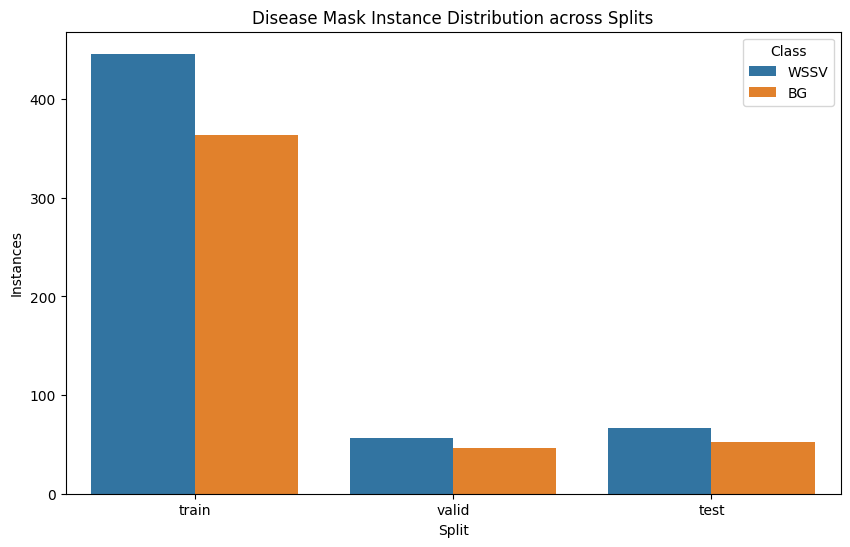

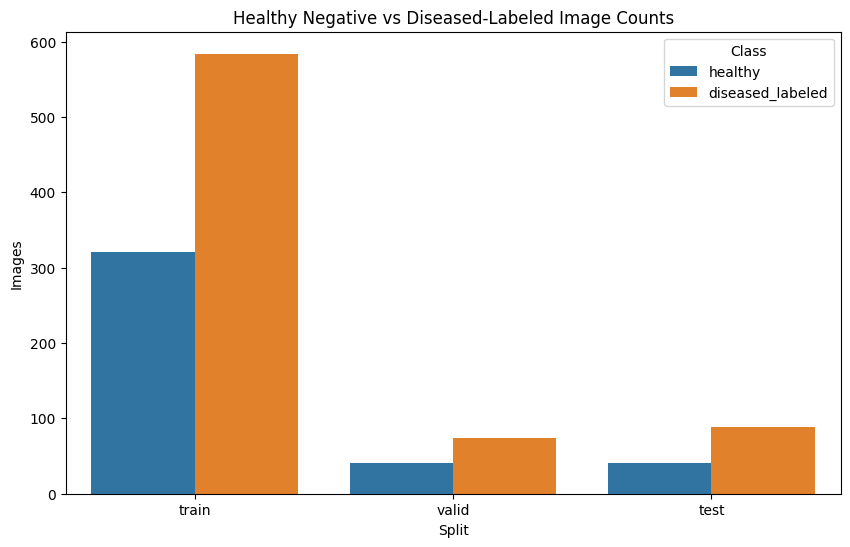

Train: 44.94% blackgill instances; 35.47% healthy negative images
Valid: 45.10% blackgill instances; 35.65% healthy negative images
Test: 43.70% blackgill instances; 31.78% healthy negative images


In [9]:
import pandas as pd
import seaborn as sns

instance_plot_data = []
image_plot_data = []
for split, split_stats in stats.items():
    image_plot_data.append({'Split': split, 'Class': HEALTHY_CLASS_NAME, 'Images': split_stats['healthy_images']})
    image_plot_data.append({'Split': split, 'Class': 'diseased_labeled', 'Images': split_stats['labeled_images']})
    for cid, count in split_stats['instance_counts'].items():
        instance_plot_data.append({'Split': split, 'Class': class_names[cid], 'Instances': count})

if instance_plot_data:
    df_instances = pd.DataFrame(instance_plot_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_instances, x='Split', y='Instances', hue='Class')
    plt.title('Disease Mask Instance Distribution across Splits')
    plt.show()

if image_plot_data:
    df_images = pd.DataFrame(image_plot_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_images, x='Split', y='Images', hue='Class')
    plt.title('Healthy Negative vs Diseased-Labeled Image Counts')
    plt.show()

for split, split_stats in stats.items():
    total_instances = sum(split_stats['instance_counts'].values())
    blackgill_ratio = (split_stats['instance_counts'].get(0, 0) / max(1, total_instances)) * 100
    healthy_ratio = (split_stats['healthy_images'] / max(1, split_stats['total_label_files'])) * 100
    print(f"{split.capitalize()}: {blackgill_ratio:.2f}% blackgill instances; {healthy_ratio:.2f}% healthy negative images")

## Training and Evaluation Helpers

In [10]:
import json
import csv
import gc
import math
import shutil
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import display

EXPERIMENT_ROOT = Path(EXPERIMENT_ROOT)
RUNS_DIR = Path(RUNS_DIR)
REPORT_DIR = EXPERIMENT_ROOT / 'reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

SMOKE_RUN = bool(globals().get('SMOKE_RUN', False))
TRAIN_IMGSZ = 320 if SMOKE_RUN else 640
TRAIN_EPOCHS = 1 if SMOKE_RUN else 100
TRAIN_BATCH = 8 if SMOKE_RUN else 16
TRAIN_PATIENCE = 1 if SMOKE_RUN else 40
RUN_TEST_EVALUATION = not SMOKE_RUN

COUNT_PENALTY_WEIGHT = 0.05
DISEASE_MISS_PENALTY_WEIGHT = 0.15
HEALTHY_FP_PENALTY_WEIGHT = 0.10
PREDICT_CONF_FOR_COUNT = 0.25

FOURIER_HYBRID_MODES = [
    {
        'mode': 'W0',
        'enabled': True,
        'fourier_enabled': False,
        'image_fourier_enabled': False,
        'feature_fourier_enabled': False,
        'default_hook_enabled': False,
        'key': 'W0_no_fourier_no_aug_hook_off_baseline',
        'name': 'W0 | no Fourier | no aug | hook off | baseline YOLO11n-seg',
        'model_yaml_key': None,
        'model_yaml': None,
        'model_variant': 'baseline',
        'fourier_module_policy': 'none',
        'image_fourier_policy': 'none',
    },
    {
        'mode': 'W1',
        'enabled': True,
        'fourier_enabled': True,
        'image_fourier_enabled': True,
        'feature_fourier_enabled': False,
        'default_hook_enabled': False,
        'key': 'W1_img_highpass_s50_a010',
        'name': 'W1 | image Fourier high-pass sigma 50 alpha 0.10',
        'model_yaml_key': None,
        'model_yaml': None,
        'model_variant': 'baseline',
        'fourier_module_policy': 'none',
        'image_fourier_policy': 'highpass_s50_a0p10',
        'image_fourier_sigmas': [50],
        'image_fourier_alphas': [0.10],
    },
    {
        'mode': 'W2',
        'enabled': True,
        'fourier_enabled': True,
        'image_fourier_enabled': True,
        'feature_fourier_enabled': False,
        'default_hook_enabled': False,
        'key': 'W2_img_highpass_s40_a010',
        'name': 'W2 | image Fourier high-pass sigma 40 alpha 0.10',
        'model_yaml_key': None,
        'model_yaml': None,
        'model_variant': 'baseline',
        'fourier_module_policy': 'none',
        'image_fourier_policy': 'highpass_s40_a0p10',
        'image_fourier_sigmas': [40],
        'image_fourier_alphas': [0.10],
    },
    {
        'mode': 'W3',
        'enabled': True,
        'fourier_enabled': True,
        'image_fourier_enabled': True,
        'feature_fourier_enabled': False,
        'default_hook_enabled': False,
        'key': 'W3_img_highpass_s50_a012',
        'name': 'W3 | image Fourier high-pass sigma 50 alpha 0.12',
        'model_yaml_key': None,
        'model_yaml': None,
        'model_variant': 'baseline',
        'fourier_module_policy': 'none',
        'image_fourier_policy': 'highpass_s50_a0p12',
        'image_fourier_sigmas': [50],
        'image_fourier_alphas': [0.12],
    },
    {
        'mode': 'W4',
        'enabled': True,
        'fourier_enabled': True,
        'image_fourier_enabled': True,
        'feature_fourier_enabled': False,
        'default_hook_enabled': False,
        'key': 'W4_img_highpass_s60_a010',
        'name': 'W4 | image Fourier high-pass sigma 60 alpha 0.10',
        'model_yaml_key': None,
        'model_yaml': None,
        'model_variant': 'baseline',
        'fourier_module_policy': 'none',
        'image_fourier_policy': 'highpass_s60_a0p10',
        'image_fourier_sigmas': [60],
        'image_fourier_alphas': [0.10],
    },
    {
        'mode': 'W5',
        'enabled': True,
        'fourier_enabled': True,
        'image_fourier_enabled': True,
        'feature_fourier_enabled': False,
        'default_hook_enabled': False,
        'key': 'W5_img_multiscale_s30a005_s80a005',
        'name': 'W5 | image Fourier multi-scale high-pass s30 a0.05 + s80 a0.05',
        'model_yaml_key': None,
        'model_yaml': None,
        'model_variant': 'baseline',
        'fourier_module_policy': 'none',
        'image_fourier_policy': 'multiscale_highpass_s30a0p05_s80a0p05',
        'image_fourier_sigmas': [30, 80],
        'image_fourier_alphas': [0.05, 0.05],
    },
    {
        'mode': 'W6',
        'enabled': True,
        'fourier_enabled': True,
        'image_fourier_enabled': True,
        'feature_fourier_enabled': True,
        'default_hook_enabled': False,
        'key': 'W6_img_s50a010_fddemcutoff_c014_g001',
        'name': 'W6 | image high-pass s50 a0.10 + FDDEMCutoff cutoff 0.14 gamma 0.01',
        'model_yaml_key': 'w6_img_hp50a010_fddemcutoff_c014_g001',
        'model_yaml': str(HYBRID_YAML_PATHS['w6_img_hp50a010_fddemcutoff_c014_g001']),
        'model_variant': 'hybrid_img_hp50_fddemcutoff014',
        'fourier_module_policy': 'fddemcutoff_cutoff0p14_gamma0p01',
        'image_fourier_policy': 'highpass_s50_a0p10',
        'image_fourier_sigmas': [50],
        'image_fourier_alphas': [0.10],
    },
    {
        'mode': 'W7',
        'enabled': True,
        'fourier_enabled': True,
        'image_fourier_enabled': True,
        'feature_fourier_enabled': True,
        'default_hook_enabled': False,
        'key': 'W7_img_s50a010_fddem_twoband_identity',
        'name': 'W7 | image high-pass s50 a0.10 + FDDEM two-band identity',
        'model_yaml_key': 'w7_img_hp50a010_fddem_twoband_identity',
        'model_yaml': str(HYBRID_YAML_PATHS['w7_img_hp50a010_fddem_twoband_identity']),
        'model_variant': 'hybrid_img_hp50_fddem_twoband_identity',
        'fourier_module_policy': 'fddem_twoband_gamma0_identity',
        'image_fourier_policy': 'highpass_s50_a0p10',
        'image_fourier_sigmas': [50],
        'image_fourier_alphas': [0.10],
    },
]

EXPERIMENTS = [mode for mode in FOURIER_HYBRID_MODES if mode.get('enabled', True)]






NO_AUG_TRAIN_ARGS = {
    # No Fourier, no preprocessing, no explicit YOLO augmentation.
    # The hidden Albumentations hook is separately disabled before training.
    'auto_augment': None,
    'erasing': 0.0,
    'mosaic': 0.0,
    'mixup': 0.0,
    'cutmix': 0.0,
    'copy_paste': 0.0,
    'fliplr': 0.0,
    'flipud': 0.0,
    'hsv_h': 0.0,
    'hsv_s': 0.0,
    'hsv_v': 0.0,
    'degrees': 0.0,
    'translate': 0.0,
    'scale': 0.0,
    'shear': 0.0,
    'perspective': 0.0,
    'multi_scale': False,
    'bgr': 0.0,
    'close_mosaic': 0,
}


FOURIER_SIGMA = 50
FOURIER_ALPHA = 0.10
FOURIER_BATCH_SIZE = 4
USE_GPU_FOURIER = True
_FOURIER_LOWPASS_CACHE = {}


STRICT_NO_AUG_KEYS = [
    'erasing', 'mosaic', 'mixup', 'cutmix', 'copy_paste', 'fliplr', 'flipud',
    'hsv_h', 'hsv_s', 'hsv_v', 'degrees', 'translate', 'scale', 'shear',
    'perspective', 'bgr', 'close_mosaic',
]


def assert_strict_no_augmentation(train_args, exp):
    if exp.get('default_hook_enabled'):
        raise AssertionError(f"{exp['mode']} tried to enable the hidden/default Albumentations hook.")
    if train_args.get('auto_augment', None) is not None:
        raise AssertionError(f"{exp['mode']} auto_augment must stay None.")
    if bool(train_args.get('multi_scale', False)):
        raise AssertionError(f"{exp['mode']} multi_scale must stay False.")
    nonzero = {key: train_args.get(key) for key in STRICT_NO_AUG_KEYS if float(train_args.get(key, 0.0) or 0.0) != 0.0}
    if nonzero:
        raise AssertionError(f"{exp['mode']} has nonzero augmentation knobs: {nonzero}")
    return True


def train_args_for_mode(exp):
    train_args = dict(NO_AUG_TRAIN_ARGS)
    assert_strict_no_augmentation(train_args, exp)
    return train_args


def augmentation_policy_name(exp):
    return 'none_all_yolo_aug_zero_hidden_hook_off'


def model_yaml_for_mode(exp):
    value = exp.get('model_yaml')
    return str(value) if value else None


def build_yolo_for_mode(exp):
    model_yaml = model_yaml_for_mode(exp)
    if model_yaml:
        model = YOLO(model_yaml)
        model.load(YOLO_MODEL)
        return model
    return YOLO(YOLO_MODEL)




def fourier_device():
    if USE_GPU_FOURIER and torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


def fourier_lowpass(height, width, sigma, device):
    key = (int(height), int(width), float(sigma), str(device))
    cached = _FOURIER_LOWPASS_CACHE.get(key)
    if cached is not None:
        return cached
    y = torch.arange(height, dtype=torch.float32, device=device) - height / 2.0
    x = torch.arange(width, dtype=torch.float32, device=device) - width / 2.0
    yy, xx = torch.meshgrid(y, x, indexing='ij')
    lowpass = torch.exp(-(xx * xx + yy * yy) / (2.0 * float(sigma) * float(sigma)))
    lowpass = lowpass[None, None, :, :]
    _FOURIER_LOWPASS_CACHE[key] = lowpass
    return lowpass


def fourier_highpass_boost_image_cpu(img, sigma=FOURIER_SIGMA, alpha=FOURIER_ALPHA):
    img_float = img.astype(np.float32)
    height, width = img_float.shape[:2]
    y = np.arange(height, dtype=np.float32) - height / 2.0
    x = np.arange(width, dtype=np.float32) - width / 2.0
    xx, yy = np.meshgrid(x, y)
    lowpass = np.exp(-(xx * xx + yy * yy) / (2.0 * float(sigma) * float(sigma))).astype(np.float32)
    enhanced_channels = []
    for channel_idx in range(img_float.shape[2]):
        channel = img_float[:, :, channel_idx]
        freq = np.fft.fftshift(np.fft.fft2(channel))
        low_freq = freq * lowpass
        low = np.fft.ifft2(np.fft.ifftshift(low_freq)).real
        high = channel - low
        enhanced_channels.append(channel + float(alpha) * high)
    enhanced = np.stack(enhanced_channels, axis=2)
    return np.clip(enhanced, 0, 255).astype(np.uint8)


def fourier_highpass_boost_batch_torch(imgs, sigma=FOURIER_SIGMA, alpha=FOURIER_ALPHA, device=None):
    if not imgs:
        return []
    if device is None:
        device = fourier_device()
    if device.type != 'cuda':
        return [fourier_highpass_boost_image_cpu(img, sigma=sigma, alpha=alpha) for img in imgs]

    arr = np.stack(imgs, axis=0).astype(np.float32)
    tensor = torch.from_numpy(arr).to(device=device, non_blocking=True).permute(0, 3, 1, 2).contiguous()
    height, width = tensor.shape[-2:]
    lowpass = fourier_lowpass(height, width, sigma, device)
    freq = torch.fft.fftshift(torch.fft.fft2(tensor, dim=(-2, -1)), dim=(-2, -1))
    low_freq = freq * lowpass
    low = torch.fft.ifft2(torch.fft.ifftshift(low_freq, dim=(-2, -1)), dim=(-2, -1)).real
    enhanced = torch.clamp(tensor + float(alpha) * (tensor - low), 0, 255)
    out = enhanced.permute(0, 2, 3, 1).byte().cpu().numpy()
    return [out[i] for i in range(out.shape[0])]


def apply_fourier_batch(image_batch, path_batch, sigma, alpha, device):
    if not image_batch:
        return {'gpu_images': 0, 'cpu_images': 0, 'oom_splits': 0}
    if device.type != 'cuda':
        enhanced_batch = [fourier_highpass_boost_image_cpu(img, sigma=sigma, alpha=alpha) for img in image_batch]
        for image_path, enhanced in zip(path_batch, enhanced_batch):
            cv2.imwrite(str(image_path), enhanced)
        return {'gpu_images': 0, 'cpu_images': len(image_batch), 'oom_splits': 0}

    try:
        enhanced_batch = fourier_highpass_boost_batch_torch(image_batch, sigma=sigma, alpha=alpha, device=device)
        for image_path, enhanced in zip(path_batch, enhanced_batch):
            cv2.imwrite(str(image_path), enhanced)
        return {'gpu_images': len(image_batch), 'cpu_images': 0, 'oom_splits': 0}
    except RuntimeError as exc:
        message = str(exc).lower()
        if 'out of memory' not in message and 'cuda' not in message:
            raise
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        if len(image_batch) == 1:
            print(f'GPU Fourier failed for one image ({exc}); falling back to CPU: {path_batch[0].name}')
            enhanced = fourier_highpass_boost_image_cpu(image_batch[0], sigma=sigma, alpha=alpha)
            cv2.imwrite(str(path_batch[0]), enhanced)
            return {'gpu_images': 0, 'cpu_images': 1, 'oom_splits': 1}

        mid = len(image_batch) // 2
        print(f'GPU Fourier OOM for batch of {len(image_batch)}; retrying as {mid} + {len(image_batch) - mid}.')
        left = apply_fourier_batch(image_batch[:mid], path_batch[:mid], sigma=sigma, alpha=alpha, device=device)
        right = apply_fourier_batch(image_batch[mid:], path_batch[mid:], sigma=sigma, alpha=alpha, device=device)
        return {
            'gpu_images': left['gpu_images'] + right['gpu_images'],
            'cpu_images': left['cpu_images'] + right['cpu_images'],
            'oom_splits': left['oom_splits'] + right['oom_splits'] + 1,
        }

def apply_fourier_highpass_to_image_dir(image_dir, sigma=FOURIER_SIGMA, alpha=FOURIER_ALPHA, batch_size=FOURIER_BATCH_SIZE):
    image_paths = []
    for ext in IMAGE_EXTENSIONS:
        image_paths.extend(Path(image_dir).glob(f'*{ext}'))
    image_paths = sorted(image_paths)
    device = fourier_device()
    if device.type == 'cuda':
        gc.collect()
        torch.cuda.empty_cache()
    print(
        f'Applying Fourier high-pass boost to {len(image_paths)} images in {image_dir} '
        f'(sigma={sigma}, alpha={alpha}, device={device}, batch_size={batch_size})'
    )

    failed = []
    image_batch = []
    path_batch = []
    batch_shape = None
    total_gpu_images = 0
    total_cpu_images = 0
    total_oom_splits = 0

    def flush_batch():
        nonlocal image_batch, path_batch, batch_shape, total_gpu_images, total_cpu_images, total_oom_splits
        if image_batch:
            stats = apply_fourier_batch(image_batch, path_batch, sigma=sigma, alpha=alpha, device=device)
            total_gpu_images += stats['gpu_images']
            total_cpu_images += stats['cpu_images']
            total_oom_splits += stats['oom_splits']
        image_batch = []
        path_batch = []
        batch_shape = None

    for image_path in image_paths:
        img = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if img is None:
            failed.append(str(image_path))
            continue
        if batch_shape is not None and img.shape != batch_shape:
            flush_batch()
        image_batch.append(img)
        path_batch.append(image_path)
        batch_shape = img.shape
        if len(image_batch) >= batch_size:
            flush_batch()
    flush_batch()

    if device.type == 'cuda':
        torch.cuda.empty_cache()
    if failed:
        print(f'Warning: failed to read {len(failed)} images. First examples: {failed[:5]}')
    print(f'Fourier split summary for {image_dir}: gpu_images={total_gpu_images}, cpu_images={total_cpu_images}, oom_splits={total_oom_splits}')
    return {
        'images': len(image_paths),
        'failed': len(failed),
        'device': str(device),
        'batch_size': int(batch_size),
        'gpu_images': int(total_gpu_images),
        'cpu_images': int(total_cpu_images),
        'oom_splits': int(total_oom_splits),
    }

def apply_fourier_highpass_to_dataset(dataset_dir, sigma=FOURIER_SIGMA, alpha=FOURIER_ALPHA):
    summary = {}
    for split in ['train', 'valid', 'test']:
        summary[split] = apply_fourier_highpass_to_image_dir(Path(dataset_dir) / split / 'images', sigma=sigma, alpha=alpha)
    remove_yolo_label_caches(dataset_dir)
    return summary


def apply_image_fourier_for_mode(dataset_dir, exp):
    if not exp.get('image_fourier_enabled'):
        return None
    sigmas = list(exp.get('image_fourier_sigmas') or [FOURIER_SIGMA])
    alphas = list(exp.get('image_fourier_alphas') or [FOURIER_ALPHA])
    if len(sigmas) != len(alphas):
        raise ValueError(f"{exp['mode']} image_fourier_sigmas and image_fourier_alphas length mismatch.")
    policy = exp.get('image_fourier_policy', 'highpass')
    print(f"Applying image Fourier policy for {exp['mode']}: {policy} | sigmas={sigmas} | alphas={alphas}")
    summary = {'policy': policy, 'sigmas': sigmas, 'alphas': alphas, 'passes': []}
    for pass_idx, (sigma, alpha) in enumerate(zip(sigmas, alphas), start=1):
        pass_summary = apply_fourier_highpass_to_dataset(dataset_dir, sigma=float(sigma), alpha=float(alpha))
        summary['passes'].append({'pass': pass_idx, 'sigma': float(sigma), 'alpha': float(alpha), 'summary': pass_summary})
    return summary

def configure_ultralytics_albumentations_hook(disable=False):
    """Disable or restore Ultralytics' default Albumentations hook for this run."""
    try:
        import importlib
        import ultralytics.data.augment as yolo_augment
    except Exception as exc:
        print(f'Could not access Ultralytics Albumentations hook: {exc}')
        return

    if not disable:
        # Important in notebooks: a previous cell/run may already have monkey-patched
        # Albumentations. Reloading restores the original Ultralytics class.
        importlib.reload(yolo_augment)
        print('Ultralytics Albumentations hook enabled/restored for this run.')
        return

    class NoOpAlbumentations:
        contains_spatial = False

        def __init__(self, *args, **kwargs):
            self.transform = None

        def __call__(self, labels):
            return labels

    yolo_augment.Albumentations = NoOpAlbumentations
    print('Ultralytics Albumentations hook disabled for this run.')


def remove_yolo_label_caches(root):
    for cache_path in Path(root).glob('**/*.cache'):
        cache_path.unlink()
        print(f'Removed stale cache: {cache_path}')



def find_image_for_label(image_dir, label_file):
    stem = Path(label_file).stem
    for ext in IMAGE_EXTENSIONS:
        candidate = Path(image_dir) / f'{stem}{ext}'
        if candidate.exists():
            return candidate
    return None

def count_labeled_images(label_dir):
    labeled = 0
    healthy = 0
    instances = 0
    for label_path in Path(label_dir).glob('*.txt'):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        if lines:
            labeled += 1
            instances += len(lines)
        else:
            healthy += 1
    return {'labeled_images': labeled, 'healthy_images': healthy, 'instances': instances}


def write_data_yaml(dataset_dir, yaml_path, val_dir='valid', test_dir='test'):
    with open(data_yaml_path, 'r') as f:
        content = yaml.safe_load(f)
    content['train'] = str(Path(dataset_dir) / 'train' / 'images')
    content['val'] = str(Path(dataset_dir) / val_dir / 'images')
    content['test'] = str(Path(dataset_dir) / test_dir / 'images')
    with open(yaml_path, 'w') as f:
        yaml.safe_dump(content, f, sort_keys=False)
    return yaml_path


def copy_dataset_for_experiment(exp_key):
    src = Path(base_path)
    dst = EXPERIMENT_ROOT / exp_key / 'dataset'
    if dst.exists():
        shutil.rmtree(dst)
    ignore = shutil.ignore_patterns('runs', '*.cache')
    shutil.copytree(src, dst, ignore=ignore)
    remove_yolo_label_caches(dst)
    return dst


def copy_split_by_label_state(src_dataset, dst_dataset, split, want_labeled):
    src_images = Path(src_dataset) / split / 'images'
    src_labels = Path(src_dataset) / split / 'labels'
    dst_images = Path(dst_dataset) / split / 'images'
    dst_labels = Path(dst_dataset) / split / 'labels'
    dst_images.mkdir(parents=True, exist_ok=True)
    dst_labels.mkdir(parents=True, exist_ok=True)

    copied = 0
    for label_path in sorted(src_labels.glob('*.txt')):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        is_labeled = bool(lines)
        if is_labeled != want_labeled:
            continue
        image_path = find_image_for_label(src_images, label_path.name)
        if image_path is None:
            continue
        shutil.copy2(image_path, dst_images / image_path.name)
        shutil.copy2(label_path, dst_labels / label_path.name)
        copied += 1
    return copied


def make_state_eval_dataset(src_dataset, exp_key, state_name, want_labeled):
    dst = EXPERIMENT_ROOT / exp_key / f'dataset_{state_name}_eval'
    if dst.exists():
        shutil.rmtree(dst)

    for sub in ['images', 'labels']:
        (dst / 'train' / sub).mkdir(parents=True, exist_ok=True)
    copied = {}
    for split in ['valid', 'test']:
        copied[split] = copy_split_by_label_state(src_dataset, dst, split, want_labeled=want_labeled)
    yaml_path = dst / f'data_{state_name}.yaml'
    write_data_yaml(dst, yaml_path)
    print(f'{state_name} eval dataset for {exp_key}: {copied}')
    return dst, yaml_path, copied


def make_labeled_only_eval_dataset(src_dataset, exp_key):
    return make_state_eval_dataset(src_dataset, exp_key, 'labeled_only', want_labeled=True)


def make_healthy_only_eval_dataset(src_dataset, exp_key):
    return make_state_eval_dataset(src_dataset, exp_key, 'healthy_only', want_labeled=False)


def metric_value(metrics, dotted_path, default=float('nan')):
    obj = metrics
    for part in dotted_path.split('.'):
        if not hasattr(obj, part):
            return default
        obj = getattr(obj, part)
    try:
        return float(obj)
    except Exception:
        return default


def count_prediction_errors(model, images_dir, labels_dir, conf=PREDICT_CONF_FOR_COUNT):
    image_paths = []
    for ext in IMAGE_EXTENSIONS:
        image_paths.extend(Path(images_dir).glob(f'*{ext}'))
    image_paths = sorted(image_paths)
    if not image_paths:
        return {
            'images': 0,
            'gt_total': 0,
            'pred_box_total': 0,
            'pred_mask_total': 0,
            'box_count_mae': float('nan'),
            'mask_count_mae': float('nan'),
            'box_count_exact': float('nan'),
            'mask_count_exact': float('nan'),
            'disease_images': 0,
            'disease_box_miss_images': 0,
            'disease_mask_miss_images': 0,
            'disease_box_miss_rate': float('nan'),
            'disease_mask_miss_rate': float('nan'),
        }

    results = model.predict(source=[str(p) for p in image_paths], imgsz=TRAIN_IMGSZ, conf=conf, verbose=False)
    box_errors = []
    mask_errors = []
    box_exact = []
    mask_exact = []
    gt_total = 0
    pred_box_total = 0
    pred_mask_total = 0
    disease_images = 0
    disease_box_miss_images = 0
    disease_mask_miss_images = 0

    for image_path, result in zip(image_paths, results):
        label_path = Path(labels_dir) / f'{image_path.stem}.txt'
        gt_count = 0
        if label_path.exists():
            gt_count = len([line for line in label_path.read_text().splitlines() if line.strip()])
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        denom = max(1, gt_count)
        box_errors.append(abs(box_count - gt_count) / denom)
        mask_errors.append(abs(mask_count - gt_count) / denom)
        box_exact.append(float(box_count == gt_count))
        mask_exact.append(float(mask_count == gt_count))
        if gt_count > 0:
            disease_images += 1
            disease_box_miss_images += int(box_count == 0)
            disease_mask_miss_images += int(mask_count == 0)
        gt_total += gt_count
        pred_box_total += box_count
        pred_mask_total += mask_count

    disease_box_miss_rate = disease_box_miss_images / disease_images if disease_images else float('nan')
    disease_mask_miss_rate = disease_mask_miss_images / disease_images if disease_images else float('nan')
    return {
        'images': len(image_paths),
        'gt_total': gt_total,
        'pred_box_total': pred_box_total,
        'pred_mask_total': pred_mask_total,
        'box_count_mae': sum(box_errors) / len(box_errors),
        'mask_count_mae': sum(mask_errors) / len(mask_errors),
        'box_count_exact': sum(box_exact) / len(box_exact),
        'mask_count_exact': sum(mask_exact) / len(mask_exact),
        'disease_images': disease_images,
        'disease_box_miss_images': disease_box_miss_images,
        'disease_mask_miss_images': disease_mask_miss_images,
        'disease_box_miss_rate': disease_box_miss_rate,
        'disease_mask_miss_rate': disease_mask_miss_rate,
    }


def healthy_false_positive_summary(model, images_dir, conf=PREDICT_CONF_FOR_COUNT):
    image_paths = []
    for ext in IMAGE_EXTENSIONS:
        image_paths.extend(Path(images_dir).glob(f'*{ext}'))
    image_paths = sorted(image_paths)
    if not image_paths:
        return {
            'healthy_images': 0,
            'healthy_images_with_box_fp': 0,
            'healthy_images_with_mask_fp': 0,
            'healthy_box_fp_rate': float('nan'),
            'healthy_mask_fp_rate': float('nan'),
            'healthy_fp_boxes_total': 0,
            'healthy_fp_masks_total': 0,
            'healthy_fp_boxes_per_image': float('nan'),
            'healthy_fp_masks_per_image': float('nan'),
            'healthy_avg_fp_confidence': float('nan'),
        }

    results = model.predict(source=[str(p) for p in image_paths], imgsz=TRAIN_IMGSZ, conf=conf, verbose=False)
    images_with_box_fp = 0
    images_with_mask_fp = 0
    box_total = 0
    mask_total = 0
    confidences = []

    for result in results:
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        if box_count > 0:
            images_with_box_fp += 1
            try:
                confidences.extend([float(v) for v in result.boxes.conf.detach().cpu().tolist()])
            except Exception:
                pass
        if mask_count > 0:
            images_with_mask_fp += 1
        box_total += box_count
        mask_total += mask_count

    n = len(image_paths)
    return {
        'healthy_images': n,
        'healthy_images_with_box_fp': images_with_box_fp,
        'healthy_images_with_mask_fp': images_with_mask_fp,
        'healthy_box_fp_rate': images_with_box_fp / n,
        'healthy_mask_fp_rate': images_with_mask_fp / n,
        'healthy_fp_boxes_total': box_total,
        'healthy_fp_masks_total': mask_total,
        'healthy_fp_boxes_per_image': box_total / n,
        'healthy_fp_masks_per_image': mask_total / n,
        'healthy_avg_fp_confidence': sum(confidences) / len(confidences) if confidences else 0.0,
    }


def healthy_aware_score(labeled_map50, count_summary, healthy_fp_summary):
    count_penalty = COUNT_PENALTY_WEIGHT * count_summary['mask_count_mae']
    disease_miss_penalty = DISEASE_MISS_PENALTY_WEIGHT * count_summary['disease_box_miss_rate']
    healthy_fp_penalty = HEALTHY_FP_PENALTY_WEIGHT * healthy_fp_summary['healthy_mask_fp_rate']
    return labeled_map50 - count_penalty - disease_miss_penalty - healthy_fp_penalty


def read_best_epoch_from_results(run_path):
    results_csv = Path(run_path) / 'results.csv'
    if not results_csv.exists():
        return {}
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    mask_col = 'metrics/mAP50(M)'
    if mask_col not in df.columns:
        return {'epochs_ran': len(df)}
    best_idx = df[mask_col].idxmax()
    first = df.iloc[0]
    best = df.iloc[best_idx]
    last = df.iloc[-1]
    return {
        'epochs_ran': int(len(df)),
        'best_epoch_by_mask_map50': int(best['epoch']) if 'epoch' in df.columns else int(best_idx + 1),
        'first_train_seg_loss': float(first.get('train/seg_loss', float('nan'))),
        'best_val_mask_map50': float(best.get(mask_col, float('nan'))),
        'best_val_mask_map50_95': float(best.get('metrics/mAP50-95(M)', float('nan'))),
        'last_val_mask_map50': float(last.get(mask_col, float('nan'))),
        'last_val_mask_map50_95': float(last.get('metrics/mAP50-95(M)', float('nan'))),
        'last_train_seg_loss': float(last.get('train/seg_loss', float('nan'))),
        'last_val_seg_loss': float(last.get('val/seg_loss', float('nan'))),
        'seg_loss_gap_val_minus_train': float(last.get('val/seg_loss', float('nan')) - last.get('train/seg_loss', float('nan'))),
    }


def run_experiment(exp):
    print('\n' + '#' * 90)
    print(f"Starting experiment: {exp['name']}")
    print('#' * 90)

    dataset_dir = copy_dataset_for_experiment(exp['key'])
    if exp.get('image_fourier_enabled'):
        fourier_transform_summary = apply_image_fourier_for_mode(dataset_dir, exp)
    else:
        fourier_transform_summary = None
        print('Fixed image Fourier preprocessing disabled for this mode; dataset images remain original.')

    remove_yolo_label_caches(dataset_dir)
    yaml_path = dataset_dir / 'data.yaml'
    write_data_yaml(dataset_dir, yaml_path)
    labeled_eval_dir, labeled_eval_yaml, _ = make_labeled_only_eval_dataset(dataset_dir, exp['key'])
    healthy_eval_dir, healthy_eval_yaml, _ = make_healthy_only_eval_dataset(dataset_dir, exp['key'])

    split_counts = {}
    actual_image_files = {}
    for split in ['train', 'valid', 'test']:
        split_counts[split] = count_labeled_images(dataset_dir / split / 'labels')
        image_dir = dataset_dir / split / 'images'
        actual_image_files[split] = sum(1 for ext in IMAGE_EXTENSIONS for image_path in image_dir.glob(f'*{ext}') if image_path.is_file())
        print(f'{exp["key"]} {split}: {split_counts[split]} | actual_image_files={actual_image_files[split]}')

    training_seed = int(globals().get('CURRENT_RUN_SEED', 42))
    run_name = f'{RUN_BASE_NAME}_seed{training_seed}_{exp["key"]}' + ('_smoke' if SMOKE_RUN else '')
    hook_disabled = True
    if exp.get('default_hook_enabled'):
        raise AssertionError('Default/hidden Albumentations hook must stay disabled in this notebook.')
    configure_ultralytics_albumentations_hook(disable=True)
    yolo = build_yolo_for_mode(exp)
    current_params_million = round(sum(p.numel() for p in yolo.model.parameters()) / 1_000_000, 3)
    start = time.time()
    yolo.train(data=str(yaml_path), task='segment', imgsz=TRAIN_IMGSZ, epochs=TRAIN_EPOCHS, batch=TRAIN_BATCH, patience=TRAIN_PATIENCE, seed=training_seed, project=str(RUNS_DIR), name=run_name, exist_ok=True, pretrained=True, plots=not SMOKE_RUN, verbose=True, **train_args_for_mode(exp))
    train_time_min = (time.time() - start) / 60

    run_path = RUNS_DIR / run_name
    best_path = run_path / 'weights' / 'best.pt'
    best_model = YOLO(str(best_path))

    full_val = best_model.val(data=str(yaml_path), split='val', imgsz=TRAIN_IMGSZ, plots=not SMOKE_RUN, verbose=False)
    labeled_val = best_model.val(data=str(labeled_eval_yaml), split='val', imgsz=TRAIN_IMGSZ, plots=False, verbose=False)
    labeled_val_count = count_prediction_errors(best_model, labeled_eval_dir / 'valid' / 'images', labeled_eval_dir / 'valid' / 'labels')
    healthy_val_fp = healthy_false_positive_summary(best_model, healthy_eval_dir / 'valid' / 'images')
    labeled_val_map50 = metric_value(labeled_val, 'seg.map50')
    val_score = healthy_aware_score(labeled_val_map50, labeled_val_count, healthy_val_fp)

    row = {
        'experiment': exp['key'], 'mode': exp.get('mode'), 'name': exp['name'], 'model': YOLO_MODEL,
        'run_name': run_name, 'run_path': str(run_path), 'best_pt': str(best_path), 'smoke_run': SMOKE_RUN,
        'training_seed': training_seed, 'fourier_enabled': bool(exp.get('fourier_enabled')),
        'image_fourier_enabled': bool(exp.get('image_fourier_enabled')), 'feature_fourier_enabled': bool(exp.get('feature_fourier_enabled')),
        'clean_light_aug_enabled': False, 'default_hook_enabled': False,
        'model_variant': exp.get('model_variant', 'baseline'), 'model_yaml_key': exp.get('model_yaml_key'), 'model_yaml': model_yaml_for_mode(exp),
        'fourier_module_policy': exp.get('fourier_module_policy', 'none'), 'params_million': current_params_million,
        'baseline_augmentation_policy': augmentation_policy_name(exp), 'hidden_albumentations_disabled': hook_disabled,
        'preprocessing_policy': exp.get('image_fourier_policy', 'none') if exp.get('image_fourier_enabled') else 'none',
        'image_fourier_policy': exp.get('image_fourier_policy', 'none'),
        'image_fourier_sigmas': '|'.join(str(x) for x in exp.get('image_fourier_sigmas', [])),
        'image_fourier_alphas': '|'.join(str(x) for x in exp.get('image_fourier_alphas', [])),
        'fourier_policy': '+'.join([p for p in [exp.get('image_fourier_policy', 'none') if exp.get('image_fourier_enabled') else 'none', exp.get('fourier_module_policy', 'none') if exp.get('feature_fourier_enabled') else 'none'] if p != 'none']) or 'none',
        'fourier_sigma': '|'.join(str(x) for x in exp.get('image_fourier_sigmas', [])) or None, 'fourier_alpha': '|'.join(str(x) for x in exp.get('image_fourier_alphas', [])) or None,
        'ultralytics_version': ultralytics.__version__, 'train_epochs_requested': TRAIN_EPOCHS, 'train_patience': TRAIN_PATIENCE,
        'actual_train_image_files': actual_image_files.get('train'), 'actual_valid_image_files': actual_image_files.get('valid'), 'actual_test_image_files': actual_image_files.get('test'),
        'fourier_transform_summary': json.dumps(fourier_transform_summary), 'train_args': json.dumps(train_args_for_mode(exp)), 'train_time_min': round(train_time_min, 2),
        'full_val_box_map50': metric_value(full_val, 'box.map50'), 'full_val_mask_map50': metric_value(full_val, 'seg.map50'),
        'labeled_val_box_map50': metric_value(labeled_val, 'box.map50'), 'labeled_val_mask_map50': labeled_val_map50,
        'labeled_val_mask_map50_95': metric_value(labeled_val, 'seg.map'), 'labeled_val_gt_instances': labeled_val_count['gt_total'],
        'labeled_val_pred_boxes': labeled_val_count['pred_box_total'], 'labeled_val_pred_masks': labeled_val_count['pred_mask_total'],
        'labeled_val_mask_count_mae': labeled_val_count['mask_count_mae'], 'labeled_val_disease_box_miss_rate': labeled_val_count['disease_box_miss_rate'],
        'labeled_val_disease_mask_miss_rate': labeled_val_count['disease_mask_miss_rate'], 'healthy_val_images': healthy_val_fp['healthy_images'],
        'healthy_val_mask_fp_rate': healthy_val_fp['healthy_mask_fp_rate'], 'healthy_val_fp_masks_per_image': healthy_val_fp['healthy_fp_masks_per_image'],
        'healthy_aware_labeled_val_mask_map50': val_score,
    }

    if RUN_TEST_EVALUATION:
        full_test = best_model.val(data=str(yaml_path), split='test', imgsz=TRAIN_IMGSZ, plots=True, verbose=False)
        labeled_test = best_model.val(data=str(labeled_eval_yaml), split='test', imgsz=TRAIN_IMGSZ, plots=False, verbose=False)
        test_count = count_prediction_errors(best_model, dataset_dir / 'test' / 'images', dataset_dir / 'test' / 'labels')
        labeled_test_count = count_prediction_errors(best_model, labeled_eval_dir / 'test' / 'images', labeled_eval_dir / 'test' / 'labels')
        healthy_test_fp = healthy_false_positive_summary(best_model, healthy_eval_dir / 'test' / 'images')
        labeled_test_map50 = metric_value(labeled_test, 'seg.map50')
        row.update({
            'full_test_box_map50': metric_value(full_test, 'box.map50'), 'full_test_box_map50_95': metric_value(full_test, 'box.map'),
            'full_test_mask_map50': metric_value(full_test, 'seg.map50'), 'full_test_mask_map50_95': metric_value(full_test, 'seg.map'),
            'labeled_test_box_map50': metric_value(labeled_test, 'box.map50'), 'labeled_test_mask_map50': labeled_test_map50,
            'labeled_test_mask_map50_95': metric_value(labeled_test, 'seg.map'), 'test_gt_instances': test_count['gt_total'],
            'test_pred_boxes': test_count['pred_box_total'], 'test_pred_masks': test_count['pred_mask_total'], 'test_mask_count_mae': test_count['mask_count_mae'],
            'labeled_test_gt_instances': labeled_test_count['gt_total'], 'labeled_test_pred_boxes': labeled_test_count['pred_box_total'],
            'labeled_test_pred_masks': labeled_test_count['pred_mask_total'], 'labeled_test_mask_count_mae': labeled_test_count['mask_count_mae'],
            'labeled_test_mask_count_exact': labeled_test_count['mask_count_exact'], 'labeled_test_disease_box_miss_rate': labeled_test_count['disease_box_miss_rate'],
            'labeled_test_disease_mask_miss_rate': labeled_test_count['disease_mask_miss_rate'], 'healthy_test_images': healthy_test_fp['healthy_images'],
            'healthy_test_mask_fp_rate': healthy_test_fp['healthy_mask_fp_rate'], 'healthy_test_box_fp_rate': healthy_test_fp['healthy_box_fp_rate'],
            'healthy_test_fp_masks_total': healthy_test_fp['healthy_fp_masks_total'], 'healthy_test_fp_masks_per_image': healthy_test_fp['healthy_fp_masks_per_image'],
            'healthy_test_avg_fp_confidence': healthy_test_fp['healthy_avg_fp_confidence'],
            'healthy_aware_labeled_test_mask_map50': healthy_aware_score(labeled_test_map50, labeled_test_count, healthy_test_fp),
        })

    row.update(read_best_epoch_from_results(run_path))
    del yolo, best_model
    gc.collect()
    return row


train_args_json = REPORT_DIR / 'train_args_only_fourier_hybrid_sweep_no_aug_hook_off_seed42.json'
train_args_payload = {'strict_no_aug_train_args': NO_AUG_TRAIN_ARGS, 'fourier_hybrid_modes': FOURIER_HYBRID_MODES, 'enabled_mode_keys': [m['key'] for m in EXPERIMENTS], 'hybrid_yaml_paths': {k: str(v) for k, v in HYBRID_YAML_PATHS.items()}, 'train_epochs_requested': TRAIN_EPOCHS, 'train_patience': TRAIN_PATIENCE}
train_args_json.write_text(json.dumps(train_args_payload, indent=2), encoding='utf-8')
print('Saved strict no-aug Fourier hybrid sweep train args:', train_args_json)

Saved strict no-aug Fourier hybrid sweep train args: /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/reports/train_args_only_fourier_hybrid_sweep_no_aug_hook_off_seed42.json


## Baseline Run

In [11]:
from collections import defaultdict
import gc
import hashlib
import random
from pathlib import Path

import pandas as pd
from IPython.display import display

# Override the baseline helper constants for this paper matrix.
EXPERIMENT_ROOT = Path(EXPERIMENT_ROOT)
RUNS_DIR = Path(RUNS_DIR)
REPORT_DIR = EXPERIMENT_ROOT / 'reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_IMGSZ = 320 if SMOKE_RUN else 640
TRAIN_EPOCHS = 1 if SMOKE_RUN else 100
TRAIN_BATCH = 8 if SMOKE_RUN else 16
TRAIN_PATIENCE = 1 if SMOKE_RUN else 40
RUN_TEST_EVALUATION = not SMOKE_RUN
PREDICT_CONF_FOR_COUNT = 0.25


def disease_stratum_for_image(image_path):
    _, disease, _, _ = parse_shrimp_group_key(Path(image_path).name)
    return str(disease).lower()


def image_split_from_strata(items_by_stratum, seed):
    rng = random.Random(seed)
    split_to_items = {'train': [], 'valid': [], 'test': []}

    for _, items in sorted(items_by_stratum.items()):
        items = list(items)
        rng.shuffle(items)
        n = len(items)
        n_train = int(round(n * TRAIN_RATIO))
        n_valid = int(round(n * VAL_RATIO))
        n_train = min(n_train, n)
        n_valid = min(n_valid, max(0, n - n_train))

        split_to_items['train'].extend(items[:n_train])
        split_to_items['valid'].extend(items[n_train:n_train + n_valid])
        split_to_items['test'].extend(items[n_train + n_valid:])

    return split_to_items


def plain_random_image_split(seed=42):
    # Deterministic naive image-level split. This intentionally allows specimen leakage
    # and does not disease-stratify, but it no longer depends on filesystem list order.
    rebuild_train_pool_from_all_splits()

    train_images_dir = Path(base_path) / 'train' / 'images'
    rng = random.Random(seed)
    image_files = sorted(
        f for f in os.listdir(train_images_dir)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    )
    if not image_files:
        raise RuntimeError('No images found in train pool after rebuilding all splits.')

    rng.shuffle(image_files)

    train_count = int(TRAIN_RATIO * len(image_files))
    valid_count = int(VAL_RATIO * len(image_files))

    split_to_files = {
        'train': image_files[:train_count],
        'valid': image_files[train_count:train_count + valid_count],
        'test': image_files[train_count + valid_count:],
    }

    for split_name in ['valid', 'test']:
        for filename in split_to_files[split_name]:
            move_image_and_label(train_images_dir / filename, split_name)

    remove_yolo_label_caches(base_path)
    print(
        'Applied deterministic naive random image split: '
        f"{len(split_to_files['train'])} train, "
        f"{len(split_to_files['valid'])} valid, "
        f"{len(split_to_files['test'])} test"
    )
    return split_records()


def stratified_random_image_split(seed=42):
    # Intentionally image-level. This is the leakage-inflated reference protocol.
    rebuild_train_pool_from_all_splits()
    images = image_files_in_split('train')
    if not images:
        raise RuntimeError('No images found in train pool after rebuilding all splits.')

    by_stratum = defaultdict(list)
    for image_path in images:
        by_stratum[disease_stratum_for_image(image_path)].append(image_path)

    split_to_images = image_split_from_strata(by_stratum, seed)
    for split_name, split_images in split_to_images.items():
        for image_path in split_images:
            move_image_and_label(image_path, split_name)

    remove_yolo_label_caches(base_path)
    print('Applied stratified random image split.')
    return split_records()


def stratified_grouped_specimen_split(seed=42):
    # Fair protocol inherited from the clean baseline notebook.
    global SEED, GROUP_SPLIT_BY_SHRIMP, GROUP_STRATIFY_BY_DISEASE, REBUILD_SPLIT_FROM_ALL_SPLITS
    SEED = seed
    GROUP_SPLIT_BY_SHRIMP = True
    GROUP_STRATIFY_BY_DISEASE = True
    REBUILD_SPLIT_FROM_ALL_SPLITS = True
    split_grouped_by_shrimp()
    remove_yolo_label_caches(base_path)
    print('Applied stratified grouped-specimen split.')
    return split_records()


def apply_split_policy(policy_key, seed=42):
    if policy_key == 'plain_random_image':
        return plain_random_image_split(seed=seed)
    if policy_key == 'stratified_random_image':
        return stratified_random_image_split(seed=seed)
    if policy_key == 'stratified_grouped_specimen':
        return stratified_grouped_specimen_split(seed=seed)
    raise ValueError(f'Unknown split policy: {policy_key}')


def split_records():
    records = []
    for split_name in ['train', 'valid', 'test']:
        for image_path in image_files_in_split(split_name):
            group_key, disease, shrimp_id, img_num = parse_shrimp_group_key(image_path.name)
            label_path = Path(base_path) / split_name / 'labels' / f'{image_path.stem}.txt'
            label_lines = []
            class_ids = []
            if label_path.exists():
                label_lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
                for line in label_lines:
                    parts = line.split()
                    if parts:
                        class_ids.append(int(float(parts[0])))
            unique_class_ids = sorted(set(class_ids))
            records.append({
                'split': split_name,
                'image': image_path.name,
                'group_key': group_key,
                'disease': str(disease).lower(),
                'shrimp_id': shrimp_id,
                'mask_instances': len(label_lines),
                'is_labeled': bool(label_lines),
                'class_ids': ','.join(str(cid) for cid in unique_class_ids),
                'has_bg_mask': 0 in unique_class_ids,
                'has_wssv_mask': 1 in unique_class_ids,
                'is_coinfection': len(unique_class_ids) >= 2,
            })
    return pd.DataFrame(records)


def save_split_artifacts(policy_key, seed):
    df = split_records().sort_values(['split', 'image']).reset_index(drop=True)
    manifest_dir = REPORT_DIR / 'split_manifests'
    manifest_dir.mkdir(parents=True, exist_ok=True)
    prefix = f'{policy_key}_seed{seed}'

    manifest_csv = manifest_dir / f'{prefix}_manifest.csv'
    summary_csv = manifest_dir / f'{prefix}_summary.csv'
    fingerprint_txt = manifest_dir / f'{prefix}_fingerprint.txt'

    df.to_csv(manifest_csv, index=False)
    summary_rows = []
    split_hashes = []
    for split in ['train', 'valid', 'test']:
        split_df = df[df['split'] == split]
        names = split_df['image'].tolist()
        split_hash = hashlib.sha256('\n'.join(names).encode()).hexdigest()
        split_hashes.append(split_hash)
        summary_rows.append({
            'split': split,
            'images': int(len(split_df)),
            'specimens': int(split_df['group_key'].nunique()),
            'labeled_images': int(split_df['is_labeled'].sum()),
            'healthy_empty_images': int((~split_df['is_labeled']).sum()),
            'bg_mask_images': int(split_df['has_bg_mask'].sum()),
            'wssv_mask_images': int(split_df['has_wssv_mask'].sum()),
            'coinfection_images': int(split_df['is_coinfection'].sum()),
            'mask_instances': int(split_df['mask_instances'].sum()),
            'split_sha256': split_hash,
        })
    pd.DataFrame(summary_rows).to_csv(summary_csv, index=False)
    fingerprint = hashlib.sha256('||'.join(split_hashes).encode()).hexdigest()
    fingerprint_txt.write_text(fingerprint + '\n', encoding='utf-8')
    print(f'Saved split manifest: {manifest_csv}')
    print(f'Saved split summary: {summary_csv}')
    print(f'Split fingerprint: {fingerprint}')
    return {
        'split_manifest_csv': str(manifest_csv),
        'split_summary_csv': str(summary_csv),
        'split_fingerprint': fingerprint,
    }


def split_metadata(policy_key, model_name, seed):
    df = split_records()
    group_sets = {
        split: set(df.loc[df['split'] == split, 'group_key'])
        for split in ['train', 'valid', 'test']
    }

    row = {
        'split_policy': policy_key,
        'model': model_name,
        'seed': seed,
        'train_images': int((df['split'] == 'train').sum()),
        'valid_images': int((df['split'] == 'valid').sum()),
        'test_images': int((df['split'] == 'test').sum()),
        'train_specimens': len(group_sets['train']),
        'valid_specimens': len(group_sets['valid']),
        'test_specimens': len(group_sets['test']),
        'train_test_group_overlap': len(group_sets['train'] & group_sets['test']),
        'train_valid_group_overlap': len(group_sets['train'] & group_sets['valid']),
        'valid_test_group_overlap': len(group_sets['valid'] & group_sets['test']),
    }

    for split in ['train', 'valid', 'test']:
        split_df = df[df['split'] == split]
        row[f'{split}_labeled_images'] = int(split_df['is_labeled'].sum())
        row[f'{split}_healthy_empty_images'] = int((~split_df['is_labeled']).sum())
        row[f'{split}_bg_mask_images'] = int(split_df['has_bg_mask'].sum())
        row[f'{split}_wssv_mask_images'] = int(split_df['has_wssv_mask'].sum())
        row[f'{split}_coinfection_images'] = int(split_df['is_coinfection'].sum())
        row[f'{split}_mask_instances'] = int(split_df['mask_instances'].sum())

    return row


def count_model_params_million(checkpoint_name):
    yolo_for_count = YOLO(checkpoint_name)
    try:
        params = sum(p.numel() for p in yolo_for_count.model.parameters())
        return round(params / 1_000_000, 3)
    finally:
        del yolo_for_count
        gc.collect()


print('Enabled strict no-aug Fourier hybrid sweep modes:', [mode['mode'] for mode in EXPERIMENTS])

paper_rows = []

for seed in SEEDS:
    for split_policy in SPLIT_POLICIES:
        print()
        print('=' * 100)
        print(f"Preparing split policy: {split_policy['key']} | seed={seed}")
        print(split_policy['description'])
        print('=' * 100)

        CURRENT_RUN_SEED = seed
        apply_split_policy(split_policy['key'], seed=seed)
        split_artifacts = save_split_artifacts(split_policy['key'], seed)

        for model_name in YOLO_MODELS:
            YOLO_MODEL = model_name
            MODEL_STEM = Path(YOLO_MODEL).stem
            RUN_BASE_NAME = f'{MODEL_STEM}_shrimp_seg_{split_policy["key"]}'
            params_million = count_model_params_million(YOLO_MODEL)

            for experiment in EXPERIMENTS:
                exp = dict(experiment)
                exp['key'] = f'{split_policy["key"]}_{MODEL_STEM}_{experiment["key"]}'
                exp['name'] = f'{split_policy["name"]} | {MODEL_STEM} | {experiment["name"]}'

                meta = split_metadata(split_policy['key'], YOLO_MODEL, seed)
                meta.update(split_artifacts)
                meta['base_params_million'] = params_million
                meta['split_policy_description'] = split_policy['description']

                result = run_experiment(exp)
                result.update(meta)
                paper_rows.append(result)

                partial_df = pd.DataFrame(paper_rows)
                partial_csv = REPORT_DIR / 'only_fourier_hybrid_sweep_no_aug_hook_off_seed42_partial.csv'
                partial_df.to_csv(partial_csv, index=False)
                display(partial_df)
                print(f'Saved partial CSV: {partial_csv}')

summary_df = pd.DataFrame(paper_rows)
summary_df = summary_df.sort_values(
    ['split_policy', 'healthy_aware_labeled_val_mask_map50', 'labeled_val_mask_map50'],
    ascending=[True, False, False],
).reset_index(drop=True)

summary_csv = REPORT_DIR / 'only_fourier_hybrid_sweep_no_aug_hook_off_seed42_summary.csv'
summary_df.to_csv(summary_csv, index=False)
print(f'Saved strict no-aug Fourier hybrid sweep summary CSV: {summary_csv}')
display(summary_df)

Enabled strict no-aug Fourier hybrid sweep modes: ['W0', 'W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7']

Preparing split policy: stratified_grouped_specimen | seed=42
Disease-stratified split where all images from one shrimp stay together.
Building shrimp-grouped, disease-stratified split:
  - BG: 60 train groups, 7 valid groups, 8 test groups
  - Healthy: 113 train groups, 14 valid groups, 15 test groups
  - WSSV: 94 train groups, 11 valid groups, 13 test groups
  - WSSV_BG: 64 train groups, 8 valid groups, 9 test groups
Shrimp-grouped split complete:
  - train: 331 shrimp groups, 905 images
    group disease counts: {'BG': 60, 'Healthy': 113, 'WSSV': 94, 'WSSV_BG': 64}
    image disease counts: {'BG': 153, 'Healthy': 321, 'WSSV': 258, 'WSSV_BG': 173}
  - valid: 40 shrimp groups, 115 images
    group disease counts: {'BG': 7, 'Healthy': 14, 'WSSV': 11, 'WSSV_BG': 8}
    image disease counts: {'BG': 21, 'Healthy': 41, 'WSSV': 32, 'WSSV_BG': 21}
  - test: 45 shrimp groups, 129 images
    gro

,experiment,mode,name,model,run_name,run_path,best_pt,smoke_run,training_seed,fourier_enabled,...,test_healthy_empty_images,test_bg_mask_images,test_wssv_mask_images,test_coinfection_images,test_mask_instances,split_manifest_csv,split_summary_csv,split_fingerprint,base_params_million,split_policy_description
0,stratified_grouped_specimen_yolo11n-seg_W0_no_...,W0,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,False,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...


Saved partial CSV: /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/reports/only_fourier_hybrid_sweep_no_aug_hook_off_seed42_partial.csv

##########################################################################################
Starting experiment: Stratified grouped-specimen split | yolo11n-seg | W1 | image Fourier high-pass sigma 50 alpha 0.10
##########################################################################################
Applying image Fourier policy for W1: highpass_s50_a0p10 | sigmas=[50] | alphas=[0.1]
Applying Fourier high-pass boost to 905 images in /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/stratified_grouped_specimen_yolo11n-seg_W1_img_highpass_s50_a010/dataset/train/images (sigma=50.0, alpha=0.1, device=cuda, batch_size=4)
Fourier split summary for /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/stratified_grouped_specimen_yolo11n-seg_W1_img_highpass_s50_a010/dataset/train/images: gpu_ima

,experiment,mode,name,model,run_name,run_path,best_pt,smoke_run,training_seed,fourier_enabled,...,test_healthy_empty_images,test_bg_mask_images,test_wssv_mask_images,test_coinfection_images,test_mask_instances,split_manifest_csv,split_summary_csv,split_fingerprint,base_params_million,split_policy_description
0,stratified_grouped_specimen_yolo11n-seg_W0_no_...,W0,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,False,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
1,stratified_grouped_specimen_yolo11n-seg_W1_img...,W1,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...


Saved partial CSV: /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/reports/only_fourier_hybrid_sweep_no_aug_hook_off_seed42_partial.csv

##########################################################################################
Starting experiment: Stratified grouped-specimen split | yolo11n-seg | W2 | image Fourier high-pass sigma 40 alpha 0.10
##########################################################################################
Applying image Fourier policy for W2: highpass_s40_a0p10 | sigmas=[40] | alphas=[0.1]
Applying Fourier high-pass boost to 905 images in /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/stratified_grouped_specimen_yolo11n-seg_W2_img_highpass_s40_a010/dataset/train/images (sigma=40.0, alpha=0.1, device=cuda, batch_size=4)
Fourier split summary for /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/stratified_grouped_specimen_yolo11n-seg_W2_img_highpass_s40_a010/dataset/train/images: gpu_ima

...

,experiment,mode,name,model,run_name,run_path,best_pt,smoke_run,training_seed,fourier_enabled,...,test_healthy_empty_images,test_bg_mask_images,test_wssv_mask_images,test_coinfection_images,test_mask_instances,split_manifest_csv,split_summary_csv,split_fingerprint,base_params_million,split_policy_description
0,stratified_grouped_specimen_yolo11n-seg_W0_no_...,W0,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,False,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
1,stratified_grouped_specimen_yolo11n-seg_W1_img...,W1,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
2,stratified_grouped_specimen_yolo11n-seg_W2_img...,W2,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
3,stratified_grouped_specimen_yolo11n-seg_W3_img...,W3,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
4,stratified_grouped_specimen_yolo11n-seg_W4_img...,W4,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
5,stratified_grouped_specimen_yolo11n-seg_W5_img...,W5,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
6,stratified_grouped_specimen_yolo11n-seg_W6_img...,W6,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...


Saved partial CSV: /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/reports/only_fourier_hybrid_sweep_no_aug_hook_off_seed42_partial.csv

##########################################################################################
Starting experiment: Stratified grouped-specimen split | yolo11n-seg | W7 | image high-pass s50 a0.10 + FDDEM two-band identity
##########################################################################################
Applying image Fourier policy for W7: highpass_s50_a0p10 | sigmas=[50] | alphas=[0.1]
Applying Fourier high-pass boost to 905 images in /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/stratified_grouped_specimen_yolo11n-seg_W7_img_s50a010_fddem_twoband_identity/dataset/train/images (sigma=50.0, alpha=0.1, device=cuda, batch_size=4)
Fourier split summary for /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/stratified_grouped_specimen_yolo11n-seg_W7_img_s50a010_fddem_twoband_iden

,experiment,mode,name,model,run_name,run_path,best_pt,smoke_run,training_seed,fourier_enabled,...,test_healthy_empty_images,test_bg_mask_images,test_wssv_mask_images,test_coinfection_images,test_mask_instances,split_manifest_csv,split_summary_csv,split_fingerprint,base_params_million,split_policy_description
0,stratified_grouped_specimen_yolo11n-seg_W0_no_...,W0,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,False,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
1,stratified_grouped_specimen_yolo11n-seg_W1_img...,W1,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
2,stratified_grouped_specimen_yolo11n-seg_W2_img...,W2,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
3,stratified_grouped_specimen_yolo11n-seg_W3_img...,W3,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
4,stratified_grouped_specimen_yolo11n-seg_W4_img...,W4,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
5,stratified_grouped_specimen_yolo11n-seg_W5_img...,W5,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
6,stratified_grouped_specimen_yolo11n-seg_W6_img...,W6,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
7,stratified_grouped_specimen_yolo11n-seg_W7_img...,W7,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt

Saved partial CSV: /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/reports/only_fourier_hybrid_sweep_no_aug_hook_off_seed42_partial.csv
Saved strict no-aug Fourier hybrid sweep summary CSV: /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/reports/only_fourier_hybrid_sweep_no_aug_hook_off_seed42_summary.csv


,experiment,mode,name,model,run_name,run_path,best_pt,smoke_run,training_seed,fourier_enabled,...,test_healthy_empty_images,test_bg_mask_images,test_wssv_mask_images,test_coinfection_images,test_mask_instances,split_manifest_csv,split_summary_csv,split_fingerprint,base_params_million,split_policy_description
0,stratified_grouped_specimen_yolo11n-seg_W3_img...,W3,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
1,stratified_grouped_specimen_yolo11n-seg_W0_no_...,W0,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,False,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
2,stratified_grouped_specimen_yolo11n-seg_W5_img...,W5,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
3,stratified_grouped_specimen_yolo11n-seg_W1_img...,W1,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
4,stratified_grouped_specimen_yolo11n-seg_W2_img...,W2,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
5,stratified_grouped_specimen_yolo11n-seg_W7_img...,W7,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
6,stratified_grouped_specimen_yolo11n-seg_W6_img...,W6,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_stratified_grouped_spec...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,True,...,41,50,64,26,119,/kaggle/working/shrimp_only_fourier_hybrid_swe...,/kaggle/working/shrimp_only_fourier_hybrid_swe...,1ffd4a250deb11598f09a0a25d1cd1522811b6e010b022...,2.877,Disease-stratified split where all images from...
7,stratified_grouped_specimen_yolo11n-seg_W4_img...,W4,Stratified grouped-specimen split | yolo11n-se...,yolo11n-seg.pt

## Compact Paper Row and Selected Checkpoint

In [12]:
paper_cols = [
    'split_policy',
    'mode',
    'model',
    'seed',
    'training_seed',
    'params_million',
    'ultralytics_version',
    'fourier_enabled',
    'image_fourier_enabled',
    'feature_fourier_enabled',
    'image_fourier_policy',
    'image_fourier_sigmas',
    'image_fourier_alphas',
    'model_variant',
    'model_yaml_key',
    'model_yaml',
    'fourier_module_policy',
    'clean_light_aug_enabled',
    'default_hook_enabled',
    'base_params_million',
    'preprocessing_policy',
    'fourier_policy',
    'fourier_sigma',
    'fourier_alpha',
    'baseline_augmentation_policy',
    'hidden_albumentations_disabled',
    'train_epochs_requested',
    'train_patience',
    'train_images',
    'valid_images',
    'test_images',
    'actual_train_image_files',
    'actual_valid_image_files',
    'actual_test_image_files',
    'train_coinfection_images',
    'valid_coinfection_images',
    'test_coinfection_images',
    'train_bg_mask_images',
    'valid_bg_mask_images',
    'test_bg_mask_images',
    'train_wssv_mask_images',
    'valid_wssv_mask_images',
    'test_wssv_mask_images',
    'train_specimens',
    'valid_specimens',
    'test_specimens',
    'train_test_group_overlap',
    'valid_test_group_overlap',
    'split_manifest_csv',
    'split_fingerprint',
    'epochs_ran',
    'best_epoch_by_mask_map50',
    'train_time_min',
    'full_test_mask_map50',
    'full_test_mask_map50_95',
    'labeled_test_mask_map50',
    'labeled_test_mask_map50_95',
    'healthy_test_mask_fp_rate',
    'healthy_test_fp_masks_per_image',
    'labeled_test_disease_mask_miss_rate',
    'labeled_test_mask_count_mae',
    'healthy_aware_labeled_val_mask_map50',
    'healthy_aware_labeled_test_mask_map50',
    'best_pt',
    'run_path',
]

available_paper_cols = [c for c in paper_cols if c in summary_df.columns]
paper_table = summary_df[available_paper_cols].copy()
paper_table_csv = REPORT_DIR / 'only_fourier_hybrid_sweep_no_aug_hook_off_seed42_paper_row.csv'
paper_table.to_csv(paper_table_csv, index=False)

print(f'Saved compact strict no-aug Fourier hybrid sweep paper row: {paper_table_csv}')
display(paper_table)

fair_rows = paper_table[paper_table['split_policy'] == 'stratified_grouped_specimen']
if not fair_rows.empty:
    print('Strict no-aug Fourier hybrid sweep grouped-specimen checkpoint by validation healthy-aware score:')
    display(fair_rows.sort_values('healthy_aware_labeled_val_mask_map50', ascending=False).head(3))

Saved compact strict no-aug Fourier hybrid sweep paper row: /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/reports/only_fourier_hybrid_sweep_no_aug_hook_off_seed42_paper_row.csv


,split_policy,mode,model,seed,training_seed,params_million,ultralytics_version,fourier_enabled,image_fourier_enabled,feature_fourier_enabled,...,labeled_test_mask_map50,labeled_test_mask_map50_95,healthy_test_mask_fp_rate,healthy_test_fp_masks_per_image,labeled_test_disease_mask_miss_rate,labeled_test_mask_count_mae,healthy_aware_labeled_val_mask_map50,healthy_aware_labeled_test_mask_map50,best_pt,run_path
0,stratified_grouped_specimen,W3,yolo11n-seg.pt,42,42,2.877,8.4.62,True,True,False,...,0.254789,0.077260,0.341463,0.390244,0.454545,0.590909,0.248238,0.122915,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...
1,stratified_grouped_specimen,W0,yolo11n-seg.pt,42,42,2.877,8.4.62,False,False,False,...,0.235374,0.060555,0.390244,0.560976,0.227273,0.429924,0.232647,0.140762,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...
2,stratified_grouped_specimen,W5,yolo11n-seg.pt,42,42,2.877,8.4.62,True,True,False,...,0.281650,0.071244,0.170732,0.195122,0.556818,0.638258,0.205890,0.149141,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...
3,stratified_grouped_specimen,W1,yolo11n-seg.pt,42,42,2.877,8.4.62,True,True,False,...,0.345105,0.088484,0.634146,0.926829,0.193182,0.839015,0.199112,0.210763,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...
4,stratified_grouped_specimen,W2,yolo11n-seg.pt,42,42,2.877,8.4.62,True,True,False,...,0.189911,0.056088,0.170732,0.195122,0.500000,0.621212,0.187053,0.066777,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...
5,stratified_grouped_specimen,W7,yolo11n-seg.pt,42,42,3.879,8.4.62,True,True,True,...,0.267320,0.062562,0.243902,0.243902,0.465909,0.579545,0.178529,0.144066,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...
6,stratified_grouped_specimen,W6,yolo11n-seg.pt,42,42,3.792,8.4.62,True,True,True,...,0.263276,0.070902,0.243902,0.243902,0.568182,0.666667,0.164194,0.120325,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...
7,stratified_grouped_specimen,W4,yolo11n-seg.pt,42,42,2.877,8.4.62,True,True,False,...,0.203805,0.057524,0.121951,0.121951,0.659091,0.706439,0.131471,0.057424,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...


Strict no-aug Fourier hybrid sweep grouped-specimen checkpoint by validation healthy-aware score:


,split_policy,mode,model,seed,training_seed,params_million,ultralytics_version,fourier_enabled,image_fourier_enabled,feature_fourier_enabled,...,labeled_test_mask_map50,labeled_test_mask_map50_95,healthy_test_mask_fp_rate,healthy_test_fp_masks_per_image,labeled_test_disease_mask_miss_rate,labeled_test_mask_count_mae,healthy_aware_labeled_val_mask_map50,healthy_aware_labeled_test_mask_map50,best_pt,run_path
0,stratified_grouped_specimen,W3,yolo11n-seg.pt,42,42,2.877,8.4.62,True,True,False,...,0.254789,0.077260,0.341463,0.390244,0.454545,0.590909,0.248238,0.122915,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...
1,stratified_grouped_specimen,W0,yolo11n-seg.pt,42,42,2.877,8.4.62,False,False,False,...,0.235374,0.060555,0.390244,0.560976,0.227273,0.429924,0.232647,0.140762,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...
2,stratified_grouped_specimen,W5,yolo11n-seg.pt,42,42,2.877,8.4.62,True,True,False,...,0.281650,0.071244,0.170732,0.195122,0.556818,0.638258,0.205890,0.149141,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...


## Final Download Checklist

In [13]:
print('Download these Kaggle/Colab outputs after training:')
print(f'1. Full Fourier hybrid summary CSV: {REPORT_DIR / "only_fourier_hybrid_sweep_no_aug_hook_off_seed42_summary.csv"}')
print(f'2. Compact paper row CSV: {REPORT_DIR / "only_fourier_hybrid_sweep_no_aug_hook_off_seed42_paper_row.csv"}')
print(f'3. Partial CSV if interrupted: {REPORT_DIR / "only_fourier_hybrid_sweep_no_aug_hook_off_seed42_partial.csv"}')
print(f'4. Split manifests: {REPORT_DIR / "split_manifests"}')
print(f'5. Generated model YAMLs: {EXPERIMENT_ROOT / "model_yamls"}')
print(f'6. Selected run folder and checkpoint from {RUNS_DIR}')
print('')
print('Selected strict no-aug Fourier hybrid checkpoint:')
if 'fair_rows' in globals() and not fair_rows.empty:
    display(fair_rows.sort_values('healthy_aware_labeled_val_mask_map50', ascending=False)[['mode', 'model_variant', 'image_fourier_policy', 'fourier_module_policy', 'healthy_aware_labeled_val_mask_map50', 'best_pt', 'run_path']].head(1))
else:
    print('No fair grouped-specimen row available yet.')

print(f'7. Train args: {REPORT_DIR / "train_args_only_fourier_hybrid_sweep_no_aug_hook_off_seed42.json"}')

import shutil
archive_path = shutil.make_archive(str(WORK_DIR / 'only_fourier_hybrid_sweep_no_aug_hook_off_seed42_outputs'), 'zip', root_dir=str(EXPERIMENT_ROOT))
print(f'8. Zip archive: {archive_path}')
try:
    from google.colab import files
    files.download(archive_path)
except Exception:
    print('Automatic browser download is only available in Colab. On Kaggle, download the archive from the working directory.')


Download these Kaggle/Colab outputs after training:
1. Full Fourier hybrid summary CSV: /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/reports/only_fourier_hybrid_sweep_no_aug_hook_off_seed42_summary.csv
2. Compact paper row CSV: /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/reports/only_fourier_hybrid_sweep_no_aug_hook_off_seed42_paper_row.csv
3. Partial CSV if interrupted: /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/reports/only_fourier_hybrid_sweep_no_aug_hook_off_seed42_partial.csv
4. Split manifests: /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/reports/split_manifests
5. Generated model YAMLs: /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/model_yamls
6. Selected run folder and checkpoint from /kaggle/working/runs/segment

Selected strict no-aug Fourier hybrid checkpoint:


,mode,model_variant,image_fourier_policy,fourier_module_policy,healthy_aware_labeled_val_mask_map50,best_pt,run_path
0,W3,baseline,highpass_s50_a0p12,none,0.248238,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...


7. Train args: /kaggle/working/shrimp_only_fourier_hybrid_sweep_no_aug_hook_off_seed42/reports/train_args_only_fourier_hybrid_sweep_no_aug_hook_off_seed42.json
8. Zip archive: /kaggle/working/only_fourier_hybrid_sweep_no_aug_hook_off_seed42_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>